all the subropuitines to segment and cluster the nuclei accfording to the 
sizds of the nucleai, the fractal dimension, the granularity, the eccentirncity

In [1]:
############  ALL ROUTINES 
import matplotlib.pyplot as plt
################################################################################################
def GaussianMixModel(density_matrix):
         ##densioty matrix MUST be the set of data!!!!!!
    from sklearn.mixture import GaussianMixture
# Apply Gaussian Mixture Model
#    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=62)
    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=62,max_iter=200,)
    gmm.fit(density_matrix)
    numeric_label = gmm.predict(density_matrix)
#print (np.sum(colors_GM ==0))
#print (np.sum(colors_GM ==1))

    colors_GM = np.where(numeric_label == 0, 'red', 'blue')

    indices_class_0 = np.where(colors_GM == 'red')[0]  # Indices of elements in class 0
    indices_class_1 = np.where(colors_GM == 'blue')[0]  # Indices of elements in class 1
    probabilities   = gmm.predict_proba(density_matrix)


    return colors_GM, probabilities, indices_class_0,indices_class_1,numeric_label
################################################################################################
def GaussianMixModel3comp(density_matrix):
         ##densioty matrix MUST be the set of data!!!!!!
    from sklearn.mixture import GaussianMixture
# Apply Gaussian Mixture Model
#    gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=62)
    gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=62,max_iter=200,)
    gmm.fit(density_matrix)
    numeric_label = gmm.predict(density_matrix)
#print (np.sum(colors_GM ==0))
#print (np.sum(colors_GM ==1))

    colors_GM = np.where(numeric_label == 0, 'red',
              np.where(numeric_label == 1, 'blue', 'green'))

    indices_class_0 = np.where(numeric_label == 0)[0]
    indices_class_1 = np.where(numeric_label == 1)[0]
    indices_class_2 = np.where(numeric_label == 2)[0]
    probabilities   = gmm.predict_proba(density_matrix)


    return colors_GM, probabilities, indices_class_0,indices_class_1,indices_class_2,numeric_label
################################################################################################

################################################################################################
def ComputeDensityMatrixKDE(x,y):
    import scipy.stats as stats

    # Stack x and y into a 2D feature matrix
    data = np.column_stack((x, y))

    # Apply Kernel Density Estimation (KDE) to estimate density matrix
    kde = stats.gaussian_kde(data.T)  # Transpose to match input format

    # Generate a grid for density matrix computation
    x_grid, y_grid = np.meshgrid(np.linspace(min(x), max(x), 100),
                             np.linspace(min(y), max(y), 100))

    # Compute density values over the grid
    density_matrix = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)
    return x_grid,y_grid,density_matrix
###########################################################################
def compute_moments(gx,gy,dmat):
    norm = dmat.sum()
    momenti     = np.zeros((6))
    momenti[0] = norm
    momenti[1] = (dmat*gx).sum() / norm
    momenti[2] = (dmat*gy).sum() / norm
    momenti[3] = (dmat*gx*gy).sum() / norm
    momenti[4] = (dmat*gx*gx).sum() / norm
    momenti[5] = (dmat*gy*gy).sum() / norm

    return momenti


total items read: 2621
total number of features: 49
total number of cell type read: 15
0 fibroblasts 884 33.7
1 plasmacell 1148 43.8
2 endothelial 254 9.7
3 Adipocytes 79 3.0
4 lymphocytes 113 4.3
5 macrophage 65 2.5
6 granulocytes 19 0.7
7 other 19 0.7
8 keratinocyte 14 0.5
9 duplicating 6 0.2
10 RBC 4 0.2
11 fibromiocytes 6 0.2
12 basalcell 4 0.2
13 vessel 1 0.0
14 apoptotic 5 0.2
 ------------ ---------------- --------------- --------------
-------- I have prepared a  df dataframe from Urdf ------
0    0.8076
1    0.6261
2    0.7198
3    0.5806
4    0.7572
Name: Cell:Eccentricity, dtype: float64
 ------------ ---------------- --------------- --------------
-------- I have prepared a  dfAreas dataframe from Urdf ------
0    173.50
1    129.75
2    213.75
3    192.25
4    208.00
Name: Cell:Area, dtype: float64


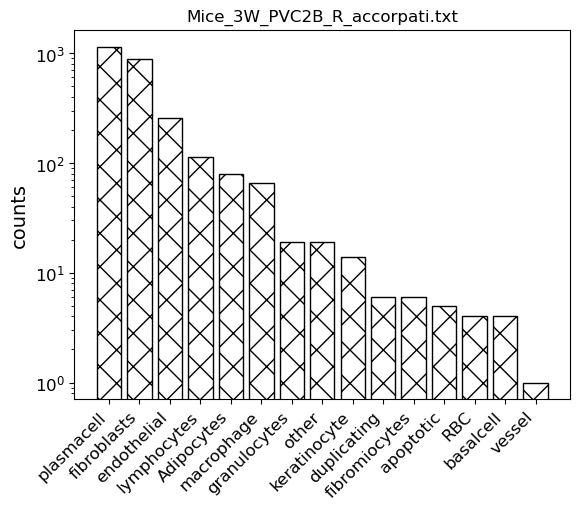

In [2]:
#################    URFILE with all the features
'''
read in the whole file that is given in output by Qupath Measuemrents. 
APART from the column Name, 

'''
### read in n
import pandas as pd

Urpath = "G:\\Shared drives\\FET-IN2SIGHT\\Work\\WP4_invivoImaging\\2025-01-30_IN2SIGHT_DATA_UNIMIB_Histology_Images_UNINA\\Qpath-Histology-Na-Implants\\"
path = Urpath
#Urname = "Mice_3W_PVC2B_R.txt"
Urname = "Mice_3W_PVC2B_R_accorpati.txt"

#Urname = "Mice_3W_PVC2A.txt"
#Urname = "Mice_3W_PVC2A_newColorDEconv.txt"
Urdf = pd.read_csv(Urpath+Urname, delimiter="\s+",   header = 0, index_col=False, dtype={
       "Image": "string" , #0 +1
        "ObjectID": "string" , #1
        "Objecttype": "string" , #2
        #"Empty": "string" , #3
        "Classification": "string" , #4
        "Parent": "string" , #5	
        "CentroidXµm": "float64",            #06
        "CentroidYµm": "float64",            #7
        "Nucleus:Area": "float64",            #8	
        "Nucleus:Perimeter": "float64",            #9	
        "Nucleus:Circularity": "float64",            #\10	
        "Nucleus:Maxcaliper": "float64",            #11	
        "Nucleus:Mincaliper": "float64",            #12	
        "Nucleus:Eccentricity": "float64",            #13	
        "Nucleus:HematoxylinODmean": "float64",            #14	
        "Nucleus:HematoxylinODsum": "float64",            #15	
        "Nucleus:HematoxylinODstddev": "float64",            #16	
        "Nucleus:HematoxylinODmax": "float64",            #17		
        "Nucleus:HematoxylinODmin": "float64",            #18		
        "Nucleus:HematoxylinODrange": "float64",            #19		
        "Nucleus:EosinODmean": "float64",            #20		
        "Nucleus:EosinODsum": "float64",            #21		
        "Nucleus:EosinODstddev": "float64",            #22		
        "Nucleus:EosinODmax": "float64",            #23		
        "Nucleus:EosinODmin": "float64",            #24	
        "Nucleus:EosinODrange": "float64",            #25		
        "Cell:Area": "float64",            #26		
        "Cell:Perimeter": "float64",            #27		
        "Cell:Circularity": "float64",            #28		
        "Cell:Maxcaliper": "float64",            #29	
        "Cell:Mincaliper": "float64",            #30	
        "Cell:Eccentricity": "float64",            #31		
        "Cell:HematoxylinODmean": "float64",            #32		
        "Cell:HematoxylinODstddev": "float64",            #33		
        "Cell:HematoxylinODmax": "float64",            #34		
        "Cell:HematoxylinODmin": "float64",            #35		
        "Cell:EosinODmean": "float64",            #36		
        "Cell:EosinODstddev": "float64",            #37		
        "Cell:EosinODmax": "float64",            #38		
        "Cell:EosinODmin": "float64",            #39		
        "Cytoplasm:HematoxylinODmean": "float64",            #40		
        "Cytoplasm:HematoxylinODstddev": "float64",            #41		
        "Cytoplasm:HematoxylinODmax": "float64",            #42
        "Cytoplasm:HematoxylinODmin": "float64",            #43	
        "Cytoplasm:EosinODmean": "float64",            #44	
        "Cytoplasm:EosinODstddev": "float64",            #45	
        "Cytoplasm:EosinODmax": "float64",            #46	
        "Cytoplasm:EosinODmin": "float64",            #47	
        "Nucleus/Cellarearation": "float64",            #48
    })


### a few checks

print ('total items read:',len(Urdf))
print ('total number of features:',len(Urdf.columns))
#print (Urdf.columns)

unique_entries  = Urdf['Classification'].unique()
NcellTypes      = len(unique_entries)
print ('total number of cell type read:', NcellTypes)

Lcells          = []
k = 0 
for U in unique_entries:
    Pcells = Urdf[Urdf['Classification']==U]
    print (k,U,len(Pcells),round(100*len(Pcells)/len(Urdf),1))
    Lcells.append([U,len(Pcells)])
    k=k+1

######create the two working Datagfrtames
labels, counts = zip(*Lcells)

dfCellsTypes = pd.DataFrame({'types':labels,'counts':counts})
# Sort by the 'Age' column in ascending order
sorted_df = dfCellsTypes.sort_values(by='counts', ascending=False)


plt.figure()
plt.bar(sorted_df['types'] ,sorted_df['counts'],facecolor='none', edgecolor='black',hatch="\/")
plt.xticks(size=12,rotation = 45,ha='right')
plt.ylabel('counts',size=14)
plt.yscale('log')
plt.yticks(fontsize=12)
plt.title(Urname)



df = Urdf[  ['Nucleus:Perimeter',
    'Nucleus:Eccentricity','Cell:Perimeter','Cell:Eccentricity','Nucleus:HematoxylinODmean',
    'Nucleus:HematoxylinODstddev','Cytoplasm:EosinODmean','Cytoplasm:EosinODstddev',
    'Image', 'ObjectID']
]

print (' ------------ ---------------- --------------- --------------')
print ('-------- I have prepared a  df dataframe from Urdf ------')
#print (df.head)
print (df['Cell:Eccentricity'][0:5])
print (' ------------ ---------------- --------------- --------------')
print ('-------- I have prepared a  dfAreas dataframe from Urdf ------')
dfAreas     = Urdf[ ['Nucleus:Area' ,'Cell:Area' ,  'Image' ,    'ObjectID']]
#print (dfAreas.head)
print (dfAreas['Cell:Area'][0:5])


---------------------------------------------------------------
---  FLAG is :  UR  --------------------------------------
---------------------------------------------------------------
-- read   2621  items from  data frame Urdf 
--- statistics of -- Mice_3W_PVC2B_R_accorpati.txt
Nucleus Perimeter 21.5  +/- 6.62
Nucleus Eccentricity 0.81  +/- 0.14
Cell Perimeter 40.43  +/- 9.72
Cell Eccentricity 0.71  +/- 0.15
NucHematMean 0.27  +/- 0.06
NucHematstd 0.09  +/- 0.03
CellEosMean 0.09  +/- 0.05
CellEosstd 0.07  +/- 0.06
-- Analysis of the correlation between Nucl. Eccent. and Cell Eccenc.
--- NOW fitting nthe density matrices :  Cell Eccentricity versus  nuceleus Eccen.
Fitted parameters: x0=0.93, y0=0.82, sigma_x=0.06, sigma_y=0.09, sigma_xy=0.08, amplitude=11.25
Fitted parameters1: x0=0.81, y0=0.70, sigma_x=0.18, sigma_y=0.16, sigma_xy=0.48, amplitude=3.99
13.633844948023878
3.9919180974552333
11.241466194231466
######### now try a classification with threshold  ##########
 ---- I am n

  File "c:\Users\giber\miniconda3\envs\GibEnv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\giber\miniconda3\envs\GibEnv\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\giber\miniconda3\envs\GibEnv\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\giber\miniconda3\envs\GibEnv\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


File Mice_3W_PVC2B_R_accorpati_PureEccentricity_clusters.csv  has been created!
<Nucl.Eccen.(class A)>= 0.91 +/- 0.046
<Nucl.Eccen.(class B)>= 0.704 +/- 0.135
<Cell.Eccen.(class A)>= 0.786 +/- 0.084
<Cell.Eccen.(class B)>= 0.623 +/- 0.156
asymmetry Nucleus Eccentricity 48.8 51.2
asymmetry Cell Eccentricity 46.9 53.1
asymmetry Cell Perimeter 42.1 57.9
asymmetry Cell Eccentricity 46.9 53.1


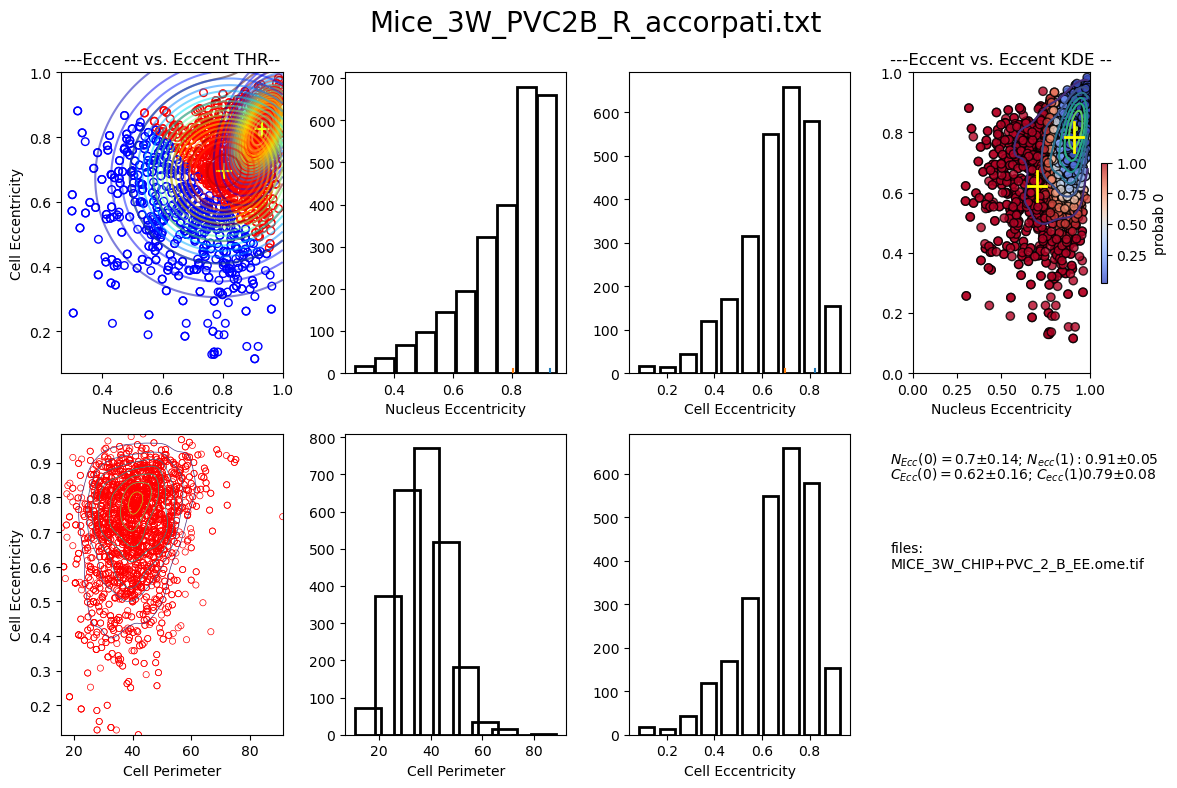

In [3]:
''' 

ONCE YOU HAVE USED QUPATH TO SEGMENT CELLS AND CREATE TWO FILES WITH 
 THIS FORMAt
file1
Nucleus:Perimeter	Nucleus:Eccentricity	Cell:Perimeter	Cell:Eccentricity
17.2021	0.7168	33.9254	0.7306
22.0398	0.4963	45.8708	0.6718
24.7338	0.8381	51.2648	0.5221
20.6906	0.7764	45.9648	0.7564
...

FILE2
Nucleus:Area	Cell:Area
19.25	90.25
48.75	157.5
25	109.25
77.5	220
24	90
....
then run below

'''
import warnings
from IPython.display import display, Math

# Suppress all warnings
warnings.filterwarnings("ignore")


from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import gaussian_kde
import scipy.optimize as opt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.optimize import curve_fit


def compute_local_density(x, y, R):
    # Define grid for density calculation
    grid_x, grid_y = np.meshgrid(np.linspace(x.min(), x.max(), 100), 
                              np.linspace(y.min(), y.max(), 100))

# Compute density using Kernel Density Estimation (KDE)
    xy = np.vstack([x, y])
    kde = gaussian_kde(xy)  # Fit KDE on scatter points
    density_matrix = kde(np.vstack([grid_x.ravel(), grid_y.ravel()])).reshape(grid_x.shape)
    return grid_x,grid_y,density_matrix


def asimmetriaDis(h):
    ia      = h.argmax()
    pmeno   = h[0:ia].sum()
    ppiu    = h[ia:].sum()
    percm   = 100*pmeno/h.sum()
    percp   = 100*ppiu/h.sum()
    return percm,percp


# Define a sum of two asymmetric 2D Gaussians
def sum_two_asymmetric_gaussians(coords, A1, x01, y01, sigma_x1, sigma_y1, alpha_x1, alpha_y1,
                                  A2, x02, y02, sigma_x2, sigma_y2, alpha_x2, alpha_y2):
    x, y = coords
    g1 = A1 * np.exp(-((x - x01)**2 / (2 * sigma_x1**2)) - ((y - y01)**2 / (2 * sigma_y1**2)))
    g1 *= np.exp(-alpha_x1 * (x - x01) - alpha_y1 * (y - y01))

    g2 = A2 * np.exp(-((x - x02)**2 / (2 * sigma_x2**2)) - ((y - y02)**2 / (2 * sigma_y2**2)))
    g2 *= np.exp(-alpha_x2 * (x - x02) - alpha_y2 * (y - y02))

    return g1 + g2  # Sum of both asymmetric Gaussians

# Define the 2D Gaussian function
def gaussian_2d(x, y, x0, y0, sigma_x, sigma_y, sigma_xy, amplitude):
    return amplitude * np.exp(-((x - x0) ** 2 / (2 * sigma_x ** 2) + (y - y0) ** 2 / (2 * sigma_y ** 2)) + (x-x0)*(y-y0) / ( (2 * sigma_xy**2)))
# Fit function
def gaussian_2dx2(coords, x0, y0, sigma_x, sigma_y, ss, amplitude, x01, y01, sigma_x1, sigma_y1, ss1, amplitude1):
    x, y = coords

    out     = amplitude * np.exp(-    (  (x - x0) ** 2 / (2 * sigma_x ** 2) + (y - y0) ** 2 / (2 * sigma_y ** 2) -(x-x0)*(y-y0)/(2*ss**2)))
    out1    = amplitude1 * np.exp(-    (  (x - x01) ** 2 / (2 * sigma_x1 ** 2) + (y - y01) ** 2 / (2 * sigma_y1 ** 2) -(x-x01)*(y-y01)/(2*ss1**2)))

    return out+out1


def fit_gaussian(coords, x0, y0, sigma_x, sigma_y, sigma_xy, amplitude):
    x, y = coords
    return gaussian_2d(x, y, x0, y0, sigma_x, sigma_y,sigma_xy, amplitude).ravel()




########################################################################################################
def Compute_density(x,y,R,params_initial):
# Compute density within radius R
    #R = 0.1  # Adjust radius as needed
    xd  = x/float(x.max())
    yd  = y/float(y.max())
    grid_x,grid_y,density_matrix = compute_local_density(xd,yd, R)
    # Fit the density matrix with the sum of two asymmetric Gaussians
    #params_initial = [1, 0.8, 0.8, 1, 1, 0.1, -0.1, 0.3, 0.3, 0.3, 1, 1, +0.05, 0.08]
    params_opt, _ = opt.curve_fit(lambda coords, *p: sum_two_asymmetric_gaussians(coords, *p), 
                              (grid_x.ravel(), grid_y.ravel()), density_matrix.ravel(), p0=params_initial)

    #print ('in  ',params_opt)
    # Generate fitted density matrix
    return grid_x,grid_y,density_matrix,params_opt
########################################################################################################
############
def countClasses(classes):
    nA = nB = nC = nE = 0
    for i in range(classes.shape[0]):
        if classes[i] == 'Class A':
            nA = nA + 1
        elif classes[i] == 'Class B':
            nB = nB + 1
        elif classes[i] == 'Class C':
            nC = nC + 1
        else:
            nE = nE + 1
    return nA,nB,nC,nE
############

def gaussian_2d(coords, x0, y0, sigma_x, sigma_y, ss, amplitude):
    x, y = coords
    return amplitude * np.exp(-    (  (x - x0) ** 2 / (2 * sigma_x ** 2) + (y - y0) ** 2 / (2 * sigma_y ** 2) -(x-x0)*(y-y0)/(2*ss**2)))

def gaussian_2dx2(coords, x0, y0, sigma_x, sigma_y, ss, amplitude, x01, y01, sigma_x1, sigma_y1, ss1, amplitude1):
    x, y = coords

    out     = amplitude * np.exp(-    (  (x - x0) ** 2 / (2 * sigma_x ** 2) + (y - y0) ** 2 / (2 * sigma_y ** 2) -(x-x0)*(y-y0)/(2*ss**2)))
    out1    = amplitude1 * np.exp(-    (  (x - x01) ** 2 / (2 * sigma_x1 ** 2) + (y - y01) ** 2 / (2 * sigma_y1 ** 2) -(x-x01)*(y-y01)/(2*ss1**2)))

    return out+out1
#######################################################################################
def CLASSIFY_THR(th1,x,y):
# Define classification rules for 2 classes
    print (' ---- I am now trying a classification over 2 classes with thresholds: ',str(th1))
    classes = np.where((x + y > th1), "Class A", "Class B")
    print ('number of A, B and Extra classes', countClasses(classes))

    # Define unique colors per class
    color_map = {"Class A": "red", "Class B": "blue"}
    colors = [color_map[label] for label in classes]
    colors_array    = np.array(colors)
##### ComputeStatFromclasses(classes)

    ind_class_A = np.where(colors_array == 'red')[0]  # Indices of elements in class 0
    ind_class_B = np.where(colors_array == 'blue')[0]  # Indices of elements in class 1
    return (colors,ind_class_A,ind_class_B)


#######################################################################################################################
########################## read in files 
##### it assumes two files with 4 columns given by Nucl. Perim., Nucle Eccent. Cell Perim. and Cell Eccentricity. 
##### the idea was to compare two regions in and out of the lenses. 
#### the third one is the file with the areas.
########## I should skip the second file.   30 May 2025
#####################################################################################
'''
It assumes that we read in 3 files 
2 files with the general perimetereccentriociy data and one with the areas

or it read the Urfile 

FLAG ='UR'
'''

FLAG = 'UR'
print ('---------------------------------------------------------------')
print ('---  FLAG is : ',FLAG,' --------------------------------------')
print ('---------------------------------------------------------------')

if FLAG != 'UR':

#path = "G:\\Shared drives\\FET-IN2SIGHT\\Work\\WP4_invivoImaging\\2025-01-30_IN2SIGHT_DATA_UNIMIB_Histology_Images_UNINA\\Qpath-Histology-Na-Implants\\analysisQupath\\"
    path = "G:\\Shared drives\\FET-IN2SIGHT\\Work\\WP4_invivoImaging\\2025-01-30_IN2SIGHT_DATA_UNIMIB_Histology_Images_UNINA\\Qpath-Histology-Na-Implants\\"
    
# Read the files using flexible spacing handling

    nome = "PerimeterEccentricy_MICE_3W_CHIP+PVC_1_C_EE.txt"

#nome         = "PerEccMICE_3W_CHIP+PVC_1_B_EE.txt"
#df          = pd.read_csv(path+nome, delimiter="\s+", engine="python")
#df          = df.astype('float64', errors='ignore')  # Will leave non-numeric columns unchanged

####  to be used to read in 
    df = pd.read_csv(path+nome, delimiter="\s+",  index_col=False, dtype={
        "Nucleus:Perimeter": "float64",            #0
        "Nucleus:Eccentricity": "float64",         #1
        "Cell:Perimeter": "float64",               #2
        "Cell:Eccentricity": "float64",            #3
        "Nucleus:HematoxyAverage": "float64",      #4
        "Nucleus:HematoxyStd": "float64",          #5
        "Cytop:EosinAverage": "float64",           #6
        "Cytop:EosinStd": "float64",               #7
        "Image": "string",                         #8
        "ObjectID": "string"                       #9
    })
    
    nome3       = "Areas_MICE_3W_CHIP+PVC_1_C_EE.txt"

    dfAreas     = pd.read_csv(path+nome3, delimiter="\s+", dtype={
        "Nucleus:Area": "float64",
        "Cell:Area": "float64",
        "Image": "string",
        "ObjectID": "string"    
    })
    print ('-- read  ',df.shape[0], ' items in ', nome)
#print ('-- read  ',dfuori.shape[0], ' items in ', nome2)
    print ('-- read  ',dfAreas.shape[0], ' items in ', nome3)
   
else:
    nome = Urname
    print ('-- read  ',df.shape[0], ' items from  data frame Urdf ')
    #print ('columns: ',df.columns)
#print (df['Cytoplasm:EosinODstddev'][0:10])

prenome = nome.split('.')[0]
uniquesFiles = list(set(df.values[:,8]))


# Rename columns for clarity
#df.columns   = ["Nucleus Perimeter", "Nucleus Eccentricity", "Cell Perimeter", "Cell Eccentricity", "filename", "cellCode"]
df.columns   = ["Nucleus Perimeter", "Nucleus Eccentricity", "Cell Perimeter", "Cell Eccentricity", "NucHematMean","NucHematstd", "CellEosMean","CellEosstd","filename", "cellCode"]
#df.columns   = ["Nucleus Perimeter", "Nucleus Eccentricity", "Cell Perimeter", "Cell Eccentricity"]
#dfuori.columns = ["Nucleus Perimeter", "Nucleus Eccentricity", "Cell Perimeter", "Cell Eccentricity"]
dfAreas.columns = ["Nucleus Area", "Cell Area", "filename", "cellCode"]
#dfAreas.columns = ["Nucleus Area", "Cell Area"]

NumTotalData    = df.shape[0]


#########################################
print ('--- statistics of -- '+ str(nome))
for k in range(df.values.shape[1]-2):
    print (df.columns[k],round(df[df.columns[k]][:].mean(),2),' +/-', round(df[df.columns[k]][:].std(),2))

print ('-- Analysis of the correlation between Nucl. Eccent. and Cell Eccenc.')
#### prepare to plot results 
F,A     = plt.subplots(2,4,figsize=(12,8))

ic  = 1   ## N. eCC.
jc  = 3   ## C. Ecc
x       =   df.values[:,ic]
NEcc    = x
xL      =   df.columns[ic]
y       =   df.values[:,jc]
CEcc    = y
yL      =   df.columns[jc]

x = np.asarray(x, dtype=np.float64)
y = np.asarray(y, dtype=np.float64)


R = 0.3               ##### to compute the density HANDMADE, obsolete USE KDE instead below 
params_initial = [1, 0.8, 0.8, 1, 1, 0.1, -0.1, 0.3, 0.3, 0.3, 1, 1, +0.05, 0.08]
grid_x,grid_y,density_matrix,params_opt = Compute_density(x,y,R,params_initial)
### write out the density matrix 
# Flatten the matrices to save in CSV format
data = np.column_stack((grid_x.ravel(), grid_y.ravel(), density_matrix.ravel()))

# Save to a CSV file
#np.savetxt(path+"gaussian_data.csv", data, delimiter=",", header="X,Y,Z", comments="")

##### NOW try fitting with Gaussians 
print ('--- NOW fitting nthe density matrices :  Cell Eccentricity versus  nuceleus Eccen.')
popt, _ = curve_fit(gaussian_2dx2, (grid_x.flatten(),grid_y.flatten()), density_matrix.flatten(), 
                     p0=[0.8, 0.73, 0.1, 0.16,0.1, 6,0.65, 0.73, 0.16, 0.16,0.15, 3],
                     maxfev=5000 )

# Retrieve parameters
x0_fit, y0_fit, sigma_x_fit, sigma_y_fit,ss, amplitude_fit,x01_fit, y01_fit, sigma1_x_fit, sigma1_y_fit,ss1, amplitude1_fit = popt
print(f"Fitted parameters: x0={x0_fit:.2f}, y0={y0_fit:.2f}, sigma_x={sigma_x_fit:.2f}, sigma_y={sigma_y_fit:.2f}, sigma_xy={ss:.2f}, amplitude={amplitude_fit:.2f}")
print(f"Fitted parameters1: x0={x01_fit:.2f}, y0={y01_fit:.2f}, sigma_x={sigma1_x_fit:.2f}, sigma_y={sigma1_y_fit:.2f}, sigma_xy={ss1:.2f}, amplitude={amplitude1_fit:.2f}")
fitted_density_matrix = gaussian_2dx2((grid_x,grid_y),*popt)
print(fitted_density_matrix.max())

###the two single copmponents 
p2 = np.copy(popt)
p2[5] = 0
p1 = np.copy(popt)
p1[11] = 0
#print ('p1: ',p1)
fitted_density_matrix2 = gaussian_2dx2((grid_x,grid_y),*p2)
print(fitted_density_matrix2.max())
#print ('p2: ',p2)
fitted_density_matrix1 = gaussian_2dx2((grid_x,grid_y),*p1)
print(fitted_density_matrix1.max())

#################### now try a classification with threshold  ############################################
#######################  OBSOLOETE                    ############################
print ('######### now try a classification with threshold  ##########')
th1         = 1.4
colors,ind_class_A,ind_class_B = CLASSIFY_THR(th1,x,y)

########### now use GAUSSIAN MIXTURE MODEL           Gauss Mix Model ############################################
print ('#### now use GAUSSIAN MIXTURE MODEL           Gauss Mix Model ################')
data                = np.column_stack((x, y))  # Shape (200, 2)
colors_GM, proba, indices_class_0,indices_class_1,numeric_labels =  GaussianMixModel(data)
x1a                 = np.mean(x[indices_class_0])
x1s                 = np.std(x[indices_class_0])
x2a                 = np.mean(x[indices_class_1])
x2s                 = np.std(x[indices_class_1])
y1a                 = np.mean(y[indices_class_0])
y1s                 = np.std(y[indices_class_0])
y2a                 = np.mean(y[indices_class_1])
y2s                 = np.std(y[indices_class_1])
mdig        = 2
StatInfo  = '$N_{Ecc}(0)=$' +str(round(x1a,mdig))+'$\pm$'+str(round(x1s,mdig)) + '; $N_{ecc}(1):$'+ str(round(x2a,2))+'$\pm$'+str(round(x2s,2))
StatInfo2 = '$C_{Ecc}(0)=$' +str(round(y1a,mdig))+'$\pm$'+str(round(y1s,mdig)) + '; $C_{ecc}(1)$'+ str(round(y2a,2))+'$\pm$'+str(round(y2s,2))
#########         write out the data on classification 
df_out      = pd.DataFrame({'Ecc.Nucl.': x, 'Ecc.Cell': y, 'label': numeric_labels, 'prob0': proba[:,0],   'ObjectID': df.values[:, 5]})
# Save to a CSV file
FF_Ecc = prenome + '_PureEccentricity_clusters.csv'
df_out.to_csv(path+FF_Ecc, index=False)
print("File "+ FF_Ecc + "  has been created!")

xG,yG,densityMat_kde= ComputeDensityMatrixKDE(x,y)
threshold           = 0.5  # Define minimum confidence level
labels              = (proba[:, 0] > threshold).astype(int)  # Assign based on probability
XKDE1a              = np.mean(x[labels==0])
XKDE1as             = np.std(x[labels==0])

XKDE1b              = np.mean(x[labels==1])
XKDE1bs             = np.std(x[labels==1])

YKDE1a              = np.mean(y[labels==0])
YKDE1as             = np.std(y[labels==0])

YKDE1b              = np.mean(y[labels==1])
YKDE1bs             = np.std(y[labels==1])
print ('<Nucl.Eccen.(class A)>=',np.round(XKDE1a,3),'+/-',np.round(XKDE1as,3))
print ('<Nucl.Eccen.(class B)>=',np.round(XKDE1b,3),'+/-',np.round(XKDE1bs,3))
print ('<Cell.Eccen.(class A)>=',np.round(YKDE1a,3),'+/-',np.round(YKDE1as,3))
print ('<Cell.Eccen.(class B)>=',np.round(YKDE1b,3),'+/-',np.round(YKDE1bs,3))

###############################################################################################
A[0,0].scatter(x, y, c="none", edgecolors=colors, s=30, marker="o")

i03         = A[0,3].scatter(x, y, c=proba[:, 0], cmap='coolwarm', edgecolors="k", alpha=0.8)
A[0,3].contour(xG,yG,densityMat_kde)
cbar1       = plt.colorbar(i03,ax=A[0,3],shrink=0.4)
cbar1.set_label('probab 0')
A[0,3].plot([XKDE1a-0.05,XKDE1a + 0.05],[YKDE1a,YKDE1a],color='yellow',linewidth = 2)
A[0,3].plot([XKDE1a,XKDE1a],[YKDE1a-0.05,YKDE1a+0.05],color='yellow',linewidth = 2)
A[0,3].plot([XKDE1b-0.05,XKDE1b + 0.05],[YKDE1b,YKDE1b],color='yellow',linewidth = 2)
A[0,3].plot([XKDE1b,XKDE1b],[YKDE1b-0.05,YKDE1b+0.05],color='yellow',linewidth = 2)

#A[0,3].text(0.5, 0.1, StatInfo, fontsize=8, color="red", ha="center")
#A[0,3].text(0.5, 0.05, StatInfo2, fontsize=8, color="red", ha="center")


#A[0,0].contourf(grid_x, grid_y, density_matrix, levels=20, cmap="viridis",alpha=0.4)
A[0,0].contour(grid_x, grid_y, fitted_density_matrix, levels=20, cmap="hot",linewidth=40, alpha = 0.5)
A[0,0].contour(grid_x, grid_y, fitted_density_matrix1, levels=20, cmap="jet",linewidth=10, alpha = 0.5)
A[0,0].contour(grid_x, grid_y, fitted_density_matrix2, levels=20, cmap="jet",linewidth=10, alpha = 0.5)
#A[0,0].plot(np.linspace(0,1,10),th1 - np.linspace(0,1,10))
A[0,0].scatter([x0_fit],[y0_fit],marker='+',s=120,color='yellow')
A[0,0].scatter([x01_fit],[y01_fit],marker='+',s=120,color='yellow')

A[0,0].set_xlabel(xL)
A[0,0].set_ylabel(yL)
A[0,0].set_title('---Eccent vs. Eccent THR--')
#A[0,0].set_xlim(0,1)
#A[0,0].set_ylim(0,1)
A[0,3].set_xlabel(xL)
#A[0,3].set_ylabel(yL)
A[0,3].set_title('---Eccent vs. Eccent KDE --')
A[0,3].set_xlim(0,1)
A[0,3].set_ylim(0,1)
    
# Compute histogram
bb  = 10
histx, binsx = np.histogram(x, bins=bb)  # Adjust 'bins' for different grouping
pm,pp = asimmetriaDis(histx)
print ('asymmetry', df.columns[ic],round(pm,1),round(pp,1) )

histy, binsy = np.histogram(y, bins=bb)  # Adjust 'bins' for different grouping
pm,pp = asimmetriaDis(histy)
print ('asymmetry', df.columns[jc],round(pm,1),round(pp,1) )

A[0,1].bar(binsx[0:bb],histx,edgecolor='black', facecolor='none', linewidth=2, width=0.065)
A[0,1].plot([x0_fit,x0_fit],[0,10])
A[0,1].plot([x01_fit,x01_fit],[0,10])

A[0,1].set_xlabel(xL)
A[0,2].bar(binsy[0:bb],histy,edgecolor='black', facecolor='none', linewidth=2, width=0.065)
A[0,2].plot([y0_fit,y0_fit],[0,10])
A[0,2].plot([y01_fit,y01_fit],[0,10])
A[0,2].set_xlabel(yL)

#### second row of the first panel

ic  = 2   ## Cell.perim
jc  = 3   ## C. ecc.
x       =   df.values[:,ic]
xL      =   df.columns[ic]
y       =   df.values[:,jc]
yL      =   df.columns[jc]

x = np.asarray(x, dtype=np.float64)
y = np.asarray(y, dtype=np.float64)

R = 0.1                 ##### to compute the density 
params_initial = [1, 0.8, 0.8, 1, 1, 0.1, -0.1, 0.3, 0.3, 0.3, 1, 1, +0.05, 0.08]
grid_x,grid_y,density_matrix,params_opt = Compute_density(x,y,R,params_initial)
grid_x  = grid_x * x.max()
grid_y  = grid_y * y.max()

A[1,0].scatter(x, y, c="none", edgecolors='red', s=20, marker="o", linewidths=0.5)
A[1,0].contour(grid_x, grid_y, density_matrix, edgecolors='red', linewidths=0.5)

A[1,0].set_xlabel(xL)
A[1,0].set_ylabel(yL)

# Compute histogram
bb  = 10
histx, binsx = np.histogram(x, bins=bb)  # Adjust 'bins' for different grouping
pm,pp = asimmetriaDis(histx)
print ('asymmetry', df.columns[ic],round(pm,1),round(pp,1) )

histy, binsy = np.histogram(y, bins=bb)  # Adjust 'bins' for different grouping
pm,pp = asimmetriaDis(histy)
print ('asymmetry', df.columns[jc],round(pm,1),round(pp,1) )

A[1,1].bar(binsx[0:bb],histx,edgecolor='black', facecolor='none', linewidth=2, width=10)
A[1,1].set_xlabel(xL)
A[1,2].bar(binsy[0:bb],histy,edgecolor='black', facecolor='none', linewidth=2, width=0.065)
A[1,2].set_xlabel(yL)


A[1, 3].axis('off')

A[1,3].set_xlim(0,1)
A[1,3].set_ylim(0,1)

nomitutti = "files:\n"
for U in uniquesFiles:
    nomitutti = nomitutti + U + '\n'
A[1,3].text(-0.1,0.5,nomitutti)
A[1,3].text(-0.1,0.9,StatInfo)
A[1,3].text(-0.1,0.85,StatInfo2)


F.suptitle(str(nome),size=20)


F.tight_layout()



total number of cell type read: 15
total number of cell type read: 14
---------------------------------------------
 
--------- feature defijntion step 1: sorted df, class0, Eccentricity: 0.704 +/- 0.135
len : 14
------------------  feature defintion step 1: sorted df, class1, Eccentricity: 0.91 +/- 0.046
len : 15
 ---- THE FINAL STEP : checking for the largest in-class occurence ----
          Type  Class  ProbEcc_Avg  ProbEcc_Std
0  fibroblasts      1     0.086154     0.000135
1   plasmacell      0     0.938110     0.000158
2  endothelial      1     0.110610     0.000691
3   Adipocytes      1     0.080732     0.002183
4  lymphocytes      0     0.973165     0.000853
5   macrophage      0     0.972001     0.002196


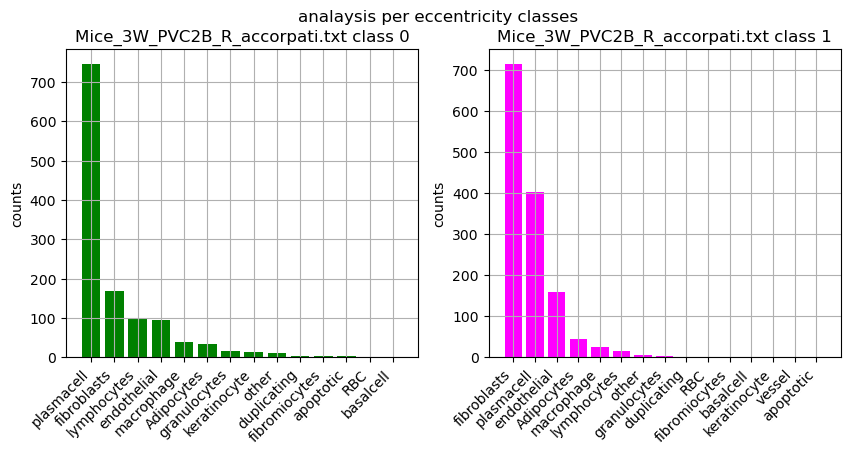

In [5]:
####### THIS IS THE PART THAT GET THE MAJOR FEATURES ABOUT THE NUCLEUS ECENTRICITY  
def GetSubsetClass(Urdf,indices_class):

    subset = Urdf.loc[indices_class]
     
    unique_entries  = subset['Classification'].unique()
    NcellTypes      = len(unique_entries)
    print ('total number of cell type read:', NcellTypes)

    Lcells          = []
    for U in unique_entries:
        Pcells = subset[subset['Classification']==U]
        #print (U,len(Pcells),round(100*len(Pcells)/len(subset),1))
        Lcells.append([U,len(Pcells)])

######create the two working Datagfrtames
    labels, counts = zip(*Lcells)

    dfCellsTypes = pd.DataFrame({'types':labels,'counts':counts})
# Sort by the 'Age' column in ascending order
    sorted_df = dfCellsTypes.sort_values(by='counts', ascending=False)
    sorted_df = sorted_df.reset_index(drop=True)
    return sorted_df

##################### create working sorted dataframe  with info on the p0roabability and classes 

def Create_dfRes(sorted_df, Urdf, indices_class,proba):
######  this is to create  the sorted df
    k_analysis = len(sorted_df)
    print ('len :',k_analysis)
######## build a working df for the class 0

    df_res0    = pd.DataFrame(columns=["Type", "ProbApp (%)", "Proba_Avg", "Proba_Std","Ncells"])

    for  k in range(k_analysis):
### for the first most popèulated one in class0
        SSdf = Urdf[Urdf["Classification"] == sorted_df['types'][k]]
         #print ('0:',k,sorted_df_0['types'][k],len(SSdf))
        matching_indices = Urdf.index[Urdf["Classification"] == sorted_df['types'][k]].tolist()
        intersection = [i for i in matching_indices if i in indices_class]
        Ncells_inters = len(intersection)
    ### now get the average value of the probability of being in class 0 only for the specific type of cell 
        proba_ave = proba[intersection,0].mean()
        proba_std = proba[intersection,0].std() /np.sqrt(Ncells_inters)
        probApp   = 100*len(intersection)/len(SSdf)  #### THIS IS THE BELONGING PROBABILITY <<<<<<<<<<<<<<
        #print (k,sorted_df['types'][k],proba_ave,proba_std)
#        if  Ncells_inters > 50 : 
#            print ('mathc 0',len(matching_indices), len(intersection),sorted_df['types'][k])
    #print (k,sorted_df_0['types'][k],sorted_df_0['counts'][k],'prob:', 
    #        round(probApp,1),'prob_class:',round(proba_ave,2),round(proba_std,2))   ##tghese are the indices that are class0 and plasmacell
    #### now create the dataframe
        df_res0.loc[len(df_res0)] = [
            sorted_df['types'][k],
            probApp,
            proba_ave,
            proba_std,
            Ncells_inters
        ]
    #print ('in',df_res0)
    return df_res0
##############################  create features 
def Create_FEATURES(dfCellsTypes,df0,df1):
    df_FEAT    = pd.DataFrame(columns=["Type","Class", "ProbAppEcc (%)", "ProbEcc_Avg", "ProbEcc_Std","Ncells"])
 
    for U in dfCellsTypes['types']:
        df0_filtered = df0[df0["Type"] == U]
        df1_filtered = df1[df1["Type"] == U]
        if not df0_filtered.empty and not df1_filtered.empty:
            p0      = df0[df0["Type"] == U]["ProbApp (%)"].iloc[0].item()    
            p1      = df1[df1["Type"] == U]["ProbApp (%)"].iloc[0].item()
            if p1>=p0:
                df_FEAT.loc[len(df_FEAT)] = [
                    U,
                    1,
                    p1,
                    df1_filtered["Proba_Avg"].iloc[0].item() ,
                    df1_filtered["Proba_Std"].iloc[0].item() , 
                    df1_filtered["Ncells"].iloc[0].item() 
                ]
            else:
                df_FEAT.loc[len(df_FEAT)] = [
                    U,
                    0,
                    p0,
                    df0_filtered["Proba_Avg"].iloc[0].item() ,
                    df0_filtered["Proba_Std"].iloc[0].item() ,
                    df0_filtered["Ncells"].iloc[0].item() 
                ]
        elif df0_filtered.empty  == True:
            p1      = df1[df1["Type"] == U]["ProbApp (%)"].iloc[0].item()    
            df_FEAT.loc[len(df_FEAT)] = [
                    U,
                    0,
                    p1,
                    df1_filtered["Proba_Avg"].iloc[0].item() ,
                    df1_filtered["Proba_Std"].iloc[0].item(),
                    df1_filtered["Ncells"].iloc[0].item() 
 
                ]
        elif df1_filtered.empty == True:
            p0      = df0[df0["Type"] == U]["ProbApp (%)"].iloc[0].item()    
            df_FEAT.loc[len(df_FEAT)] = [
                    U,
                    1,
                    p0,
                    df0_filtered["Proba_Avg"].iloc[0].item() ,
                    df0_filtered["Proba_Std"].iloc[0].item(),
                    df0_filtered["Ncells"].iloc[0].item() 
 
                ]
    return df_FEAT


######################### analaysis per eccentricity classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analaysis per eccentricity classes ')

#### create the sorted subsets 
sorted_df_1 = GetSubsetClass(Urdf,indices_class_1)

iframe = 1
A1[iframe].bar(sorted_df_1['types'] ,sorted_df_1['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df_1['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
A1[iframe].set_title(Urname+' class ' + str(iframe))
A1[iframe].grid()

#### create the sorted subsets 
sorted_df_0 = GetSubsetClass(Urdf,indices_class_0)

iframe = 0
A1[iframe].bar(sorted_df_0['types'] ,sorted_df_0['counts'],color='green')
A1[iframe].set_xticklabels(sorted_df_0['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
A1[iframe].set_title(Urname+' class '+str(iframe))
A1[iframe].grid()


### evaluation of the average eccentricity per type of cells and average probability
## colors_GM, proba, indices_class_0,indices_class_1,numeric_labels =  GaussianMixModel(data)
### we do it over class0
### let's say that we look at the first 3 most populated classes
### sorted_Df0 anjd sorted_df1 are the dataframes with the class0 and class 1 ordered

print ('---------------------------------------------\n ')
print('--------- feature defijntion step 1: sorted df, class0, Eccentricity:', np.round(x1a,3),'+/-',np.round(x1s,3))

#### these are dataframes with the probabilities of belongin to a class.
df_res0 = Create_dfRes(sorted_df_0, Urdf, indices_class_0,proba)

print ('------------------  feature defintion step 1: sorted df, class1, Eccentricity:', np.round(x2a,3),'+/-',np.round(x2s,3))
df_res1 = Create_dfRes(sorted_df_1, Urdf, indices_class_1,proba)

######### now unify the two df_res dataframe ina single ordered one where we consinder the result of the clasification onlky 
## for the class with the largest belonging probability  

print (" ---- THE FINAL STEP : checking for the largest in-class occurence ----")
#### search each of the uniques entries for the largest belonging probability and then select the corresponding class0 probability

df_FEATURES = Create_FEATURES(dfCellsTypes,df_res0,df_res1)


df_Classification_E =   pd.DataFrame(columns=["Type","Class", "ProbEcc_Avg", "ProbEcc_Std"])  

Thr_App   = 45   ### %% of presence in the classs
Thr_Count = 50   ## absolute number of cells  in total in the dataset

for k in range(len(df_FEATURES)):
    U = df_FEATURES.iloc[k]["Type"]
    C0 = dfCellsTypes[dfCellsTypes['types'] == df_FEATURES.iloc[k]["Type"]]['counts'].values[0]
    #print(U,C0,df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["Class"] )
    if df_FEATURES.iloc[k]["ProbAppEcc (%)"] > Thr_App and C0 >Thr_Count:
#        print (k,C0,df_FEATURES.iloc[k]["Type"],df_FEATURES.iloc[k]["Class"],df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["ProbEcc_Avg"])
        df_Classification_E.loc[len(df_Classification_E)] = [
                U,
                df_FEATURES.iloc[k]["Class"],
                df_FEATURES.iloc[k]["ProbEcc_Avg"],
                df_FEATURES.iloc[k]["ProbEcc_Std"]/np.sqrt(df_FEATURES.iloc[k]["Ncells"])
                 
            ]

print (df_Classification_E)



In [45]:

def Get_Vf(jcell):
    Vf = -1 * np.ones((5),dtype = 'int')

    if np.any(indices_class_0 == jcell):
        Vf[0] = 0
    else:
        Vf[0] = 1

    if np.any(indices_classFrac_0 == jcell):
        Vf[1] = 0
    else:
        Vf[1] = 1

    if np.any(indices_classG_0 == jcell):
        Vf[2] = 0
    else:
        Vf[2] = 1

    if np.any(indices_classLogA_0 == jcell):
        Vf[3] = 0
    else:
        Vf[3] = 1

    if np.any(indices_class_LinArea0 == jcell):
        Vf[4] = 0
    else:
        Vf[4] = 1

    return (Vf)

for jcell in range(10):
    Vf = Get_Vf(jcell)    
    print (jcell, Vf,df['cellCode'].iloc[jcell])

ì


0 [0 0 0 1 1] ee0c5ee9-83d9-4b61-8628-0d1796b67a2c
1 [0 0 0 1 0] 18c3d022-2e50-4364-bf14-11c0bcb83fd3
2 [1 1 1 1 1] 4e7a3ef6-da93-4cc3-8c56-62337a470f71
3 [0 0 0 1 1] c7ee5340-1f61-4b2c-b23b-04190b8e591e
4 [1 1 1 1 1] 38da938e-3b33-458a-9e9b-c3d01fe4f329
5 [1 0 1 1 0] 5c970d34-5cd1-43fd-9c59-f51f1b559a22
6 [0 0 0 1 0] 07cdd8cc-273a-4036-b311-6b296d9befc4
7 [1 0 1 1 1] 7a6c64b1-66c4-4128-a8cf-fb21749b9348
8 [1 1 1 1 1] 91c95011-64f1-4cd4-816f-f8733ed61ea3
9 [0 0 0 1 0] 5d49d6f8-7f96-485a-a4d5-42595ccd1f11


NameError: name 'ì' is not defined

Nuc. Perimiter     ;  Nucl. Area
0 23.7499 33.5
1 15.7239 18.75
2 26.6257 42.75
3 22.6993 31.5
4 23.1704 25.25
5 19.2755 24.25
6 19.6418 26.0
7 24.1379 33.25
8 29.9691 29.0
9 14.183 14.5
#### now use GAUSSIAN MIXTURE MODEL           Gauss Mix Model ################


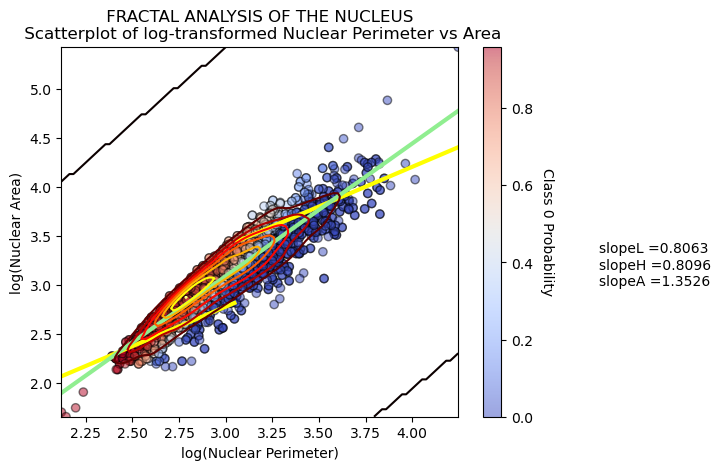

1.37 0.04
1.33 0.06
T-statistic two classes of  Nucleus fractal dimension: 22.346479930802698
P-value: 5.968360478182063e-100
-------- File Mice_3W_PVC2B_R_accorpati_FractalAnalysis.csv has been created !!!!
Main output is the varialble singleNucleus_fractal
total number of cell type read: 12
total number of cell type read: 15
0.74 0.14 0.9 0.09


Text(6, 150, 'Nuc.Ecc.=0.9+/-0.09')

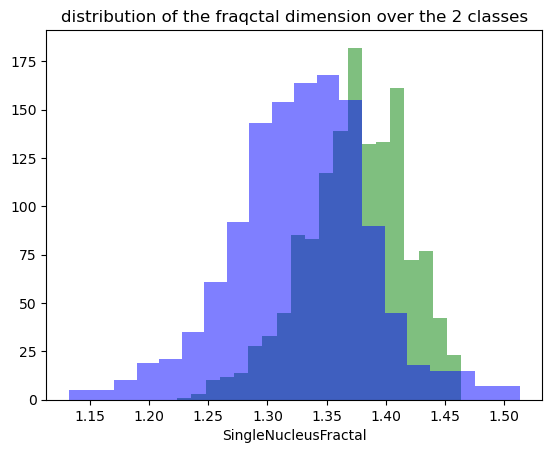

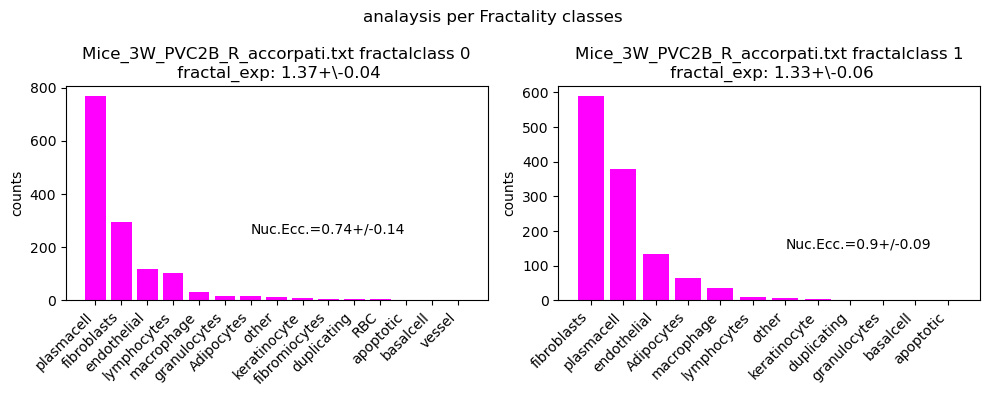

In [6]:
'''   
FRACTAL ANALYSIS OF NUCLEI 
'''
from scipy.stats import ttest_ind
NuclearPerimeter = np.asarray(df.values[:,0]      , dtype=np.float64)
NuclearArea      = np.asarray(dfAreas.values[:,0] , dtype = np.float64)
print ('Nuc. Perimiter     ;  Nucl. Area')
for k in range(10):
    print (k, NuclearPerimeter[k],NuclearArea[k])
ddelta = 1e-7
xfrac            = np.log(NuclearPerimeter + ddelta)
yfrac            = np.log(NuclearArea + ddelta)

######### THERE ARE CASE WHER EI WANT TO DIVIDE IN TWO POPULATIONS 
maskH = yfrac > 3.5
maskL = yfrac < 2.7

xfracsubL = xfrac[maskL]
yfracsubL = yfrac[maskL]
xfracsubH = xfrac[maskH]
yfracsubH = yfrac[maskH]

print ('#### now use GAUSSIAN MIXTURE MODEL           Gauss Mix Model ################')

data                = np.column_stack((xfrac, yfrac)) 
colors_GM, probaFrac,indices_classFrac_0 ,indices_classFrac_1,numeric_labels =  GaussianMixModel(data)

Id = plt.scatter(
    xfrac,
    yfrac, 
     c = probaFrac[:, 0], 
     cmap='coolwarm', 
     edgecolors="k", 
     alpha=0.5
)
plt.xlabel("log(Nuclear Perimeter)")
plt.ylabel("log(Nuclear Area)")
plt.title(" FRACTAL ANALYSIS OF THE NUCLEUS \n Scatterplot of log-transformed Nuclear Perimeter vs Area")
cbar = plt.colorbar(Id)
# Add a label to the colorbar
cbar.set_label('Class 0 Probability', rotation=270, labelpad=15)


###lin fit 

# Perform linear fit  LOW
coefficients = np.polyfit(xfracsubL, yfracsubL, 1)  # Degree 1 for linear
slopeL, interceptL = coefficients

# Predicted values
xfit = np.linspace(xfracsubL.min(),xfracsubL.max(),20)
y_fit = slopeL * xfit  +  interceptL
plt.plot(xfit,y_fit, linewidth=3,color='yellow')
S1 = 'slopeL ='+str(round(slopeL,4)) + '\n'


# Perform linear fit HIGH
coefficients = np.polyfit(xfracsubH, yfracsubH, 1)  # Degree 1 for linear
slopeH, interceptH = coefficients

# Predicted values
xfit = np.linspace(xfracsubH.min(),xfracsubH.max(),20)
y_fit = slopeH * xfit  +  interceptH
plt.plot(xfit,y_fit, linewidth=3,color='yellow')
S2 = 'slopeH ='+str(round(slopeH,4))+ '\n'
# Perform linear fit  ALL
coefficients = np.polyfit(xfrac, yfrac, 1)  # Degree 1 for linear
slopeA, interceptA = coefficients
xfit = np.linspace(xfrac.min(),xfrac.max(),20)
y_fit = slopeA * xfit  +  interceptA
plt.plot(xfit,y_fit, linewidth=3,color='lightgreen')
plt.text(5,3,S1+S2+ 'slopeA ='+str(round(slopeA,4)))

############### density matrix 

xGf,yGf,densityMat_kde = ComputeDensityMatrixKDE(xfrac,yfrac)
plt.contour(xGf,yGf,densityMat_kde,cmap= 'hot',linewidth = 15 )
plt.show()
####################   compute the siongle cell- nuclear  fractal dimension
def Avoid_negative_absurds(vec):
    positive_values = vec[vec > 0]
    average_positive = positive_values.mean()

    # Replace negative values with the average
    vec[vec < 0] = average_positive
    return vec

singleNucleus_fractalH   = (yfrac - interceptH) / xfrac 
singleNucleus_fractalH   = Avoid_negative_absurds(singleNucleus_fractalH)
singleNucleus_fractalL   = (yfrac - interceptL) / xfrac 
singleNucleus_fractalL   = Avoid_negative_absurds(singleNucleus_fractalL)
singleNucleus_fractal    = (yfrac - interceptA) / xfrac 
singleNucleus_fractal    = Avoid_negative_absurds(singleNucleus_fractal)

plt.figure()
plt.title('distribution of the fraqctal dimension over the 2 classes')
plt.hist(singleNucleus_fractal[indices_classFrac_0], bins=20, color='green',alpha=0.5)
plt.hist(singleNucleus_fractal[indices_classFrac_1], bins=20, color='blue',alpha=0.5)

avefractal_class0 = round(singleNucleus_fractal[indices_classFrac_0].mean(),2)
stdfractal_class0 = round(singleNucleus_fractal[indices_classFrac_0].std(),2)
avefractal_class1 = round(singleNucleus_fractal[indices_classFrac_1].mean(),2)
stdfractal_class1 = round(singleNucleus_fractal[indices_classFrac_1].std(),2)

print (avefractal_class0,stdfractal_class0)
print (avefractal_class1,stdfractal_class1)

plt.xlabel('SingleNucleusFractal')
t_statistic, p_value = ttest_ind(singleNucleus_fractal[indices_classFrac_0], singleNucleus_fractal[indices_classFrac_1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
print("T-statistic two classes of  Nucleus fractal dimension:", t_statistic)
print("P-value:", p_value)


# Calculate bin centers




df_out      = pd.DataFrame({'xlog': xfrac, 'ylog': yfrac, 'probClass0': probaFrac[:,0], 'fractal': singleNucleus_fractal, 'ImageID':df.values[:,9]})
# Save to a CSV file
Fout        = prenome + '_FractalAnalysis.csv'
df_out.to_csv(path+Fout, index=False)
print("-------- File " + Fout + " has been created !!!!")
print ('Main output is the varialble singleNucleus_fractal')


####################### divide per classes 

######################### analaysis per eccentricity classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analaysis per Fractality classes ')

sorted_df = GetSubsetClass(Urdf,indices_classFrac_1)   ### essential step: those items in the dataset that fall into the specific class 
iframe = 1
A1[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
A1[iframe].set_title(Urname+' fractalclass ' + str(iframe) + '\n fractal_exp: ' + str(avefractal_class1)+'+\-'+str(stdfractal_class1))

sorted_df = GetSubsetClass(Urdf,indices_classFrac_0) ### essential step: those items in the dataset that fall into the specific class
iframe = 0
A1[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
A1[iframe].set_title(Urname+' fractalclass '+str(iframe)+ '\n fractal_exp: ' + str(avefractal_class0)+'+\-'+str(stdfractal_class0))
plt.tight_layout()

##############compute Nucleus Eccentricity ont he two classes

Necc_fract0_ave = round(NEcc[indices_classFrac_0].mean(),2)
Necc_fract0_std = round(NEcc[indices_classFrac_0].std(),2)
Necc_fract1_ave = round(NEcc[indices_classFrac_1].mean(),2)
Necc_fract1_std = round(NEcc[indices_classFrac_1].std(),2)
print (Necc_fract0_ave,Necc_fract0_std,Necc_fract1_ave,Necc_fract1_std)
A1[0].text(6,250,'Nuc.Ecc.='+ str(Necc_fract0_ave)+'+/-'+str(Necc_fract0_std))

A1[1].text(6,150,'Nuc.Ecc.='+ str(Necc_fract1_ave)+'+/-'+str(Necc_fract1_std))


total number of cell type read: 12
total number of cell type read: 15
---------------------------------------------
 
--------- feature defijntion step 1: sorted df, class0, Eccentricity: [1.37, 0.04]
len : 15
------------------  feature defintion step 1: sorted df, class1, Fractality: [1.33, 0.06]
len : 12
 ---- THE FINAL STEP : checking for the largest in-class occurence ----
          Type  Class  ProbFrac_Avg  ProbFrac_Std
0  fibroblasts      1      0.102734      0.000251
1   plasmacell      0      0.820256      0.000154
2  endothelial      1      0.123798      0.001160
3   Adipocytes      1      0.076884      0.002271
4  lymphocytes      0      0.879074      0.000923
5   macrophage      1      0.092382      0.004240


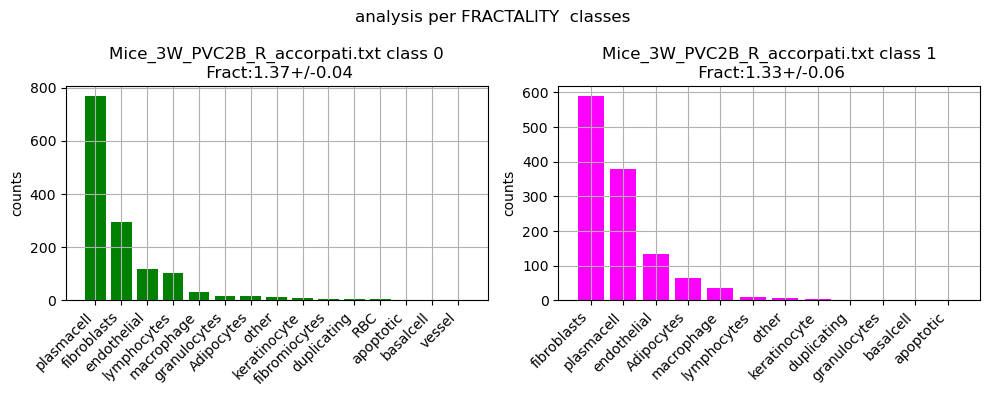

In [7]:
############ THIS IS THE PART OF THE CODE WHERE I GET THE MAJOR FEATURES ON THE GRANULARITY AND ASSIGN IT TO THE MOST 
#### INFLUENCING CELLS


######################### analaysis per FRACTALITY  classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analysis per FRACTALITY  classes ')

#### create the sorted subsets 
sorted_df_F1 = GetSubsetClass(Urdf,indices_classFrac_1)

iframe = 1
A1[iframe].bar(sorted_df_F1['types'] ,sorted_df_F1['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df_F1['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class ' + str(iframe))
A1[iframe].grid()

#### create the sorted subsets 
sorted_df_F0 = GetSubsetClass(Urdf,indices_classFrac_0)

iframe = 0
A1[iframe].bar(sorted_df_F0['types'] ,sorted_df_F0['counts'],color='green')
A1[iframe].set_xticklabels(sorted_df_F0['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class '+str(iframe))
A1[iframe].grid()


### evaluation of the average eccentricity per type of cells and average probability
## colors_GM, proba, indices_class_0,indices_class_1,numeric_labels =  GaussianMixModel(data)
### we do it over class0
### let's say that we look at the first 3 most populated classes
### sorted_Df0 anjd sorted_df1 are the dataframes with the class0 and class 1 ordered

print ('---------------------------------------------\n ')
Fract_ave0 = [np.round(avefractal_class0,3),np.round(stdfractal_class0,3)]
A1[0].set_title(Urname+' class '+str(0)+'\n Fract:'+str(Fract_ave0[0])+'+/-'+str(Fract_ave0[1]))

print('--------- feature defijntion step 1: sorted df, class0, Eccentricity:', Fract_ave0)

#### these are dataframes with the probabilities of belongin to a class.
df_resF0 = Create_dfRes(sorted_df_F0, Urdf, indices_classFrac_0,probaFrac)

Fract_ave1 = [np.round(avefractal_class1,3),np.round(stdfractal_class1,3)]
A1[1].set_title(Urname+' class '+str(1)+'\n Fract:'+str(Fract_ave1[0])+'+/-'+str(Fract_ave1[1]))
print ('------------------  feature defintion step 1: sorted df, class1, Fractality:', Fract_ave1)
df_resF1 = Create_dfRes(sorted_df_F1, Urdf, indices_classFrac_1,probaFrac)
print (" ---- THE FINAL STEP : checking for the largest in-class occurence ----")
#### search each of the uniques entries for the largest belonging probability and then select the corresponding class0 probability

df_FEATURES = Create_FEATURES(dfCellsTypes,df_resF0,df_resF1)

df_Classification_F =   pd.DataFrame(columns=["Type","Class", "ProbFrac_Avg", "ProbFrac_Std"])  

Thr_App   = 45
Thr_Count = 50
for k in range(len(df_FEATURES)):
    U = df_FEATURES.iloc[k]["Type"]
    C0 = dfCellsTypes[dfCellsTypes['types'] == df_FEATURES.iloc[k]["Type"]]['counts'].values[0]
    #print(U,C0,df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["Class"] )
    if df_FEATURES.iloc[k]["ProbAppEcc (%)"] > Thr_App and C0 >Thr_Count:
#        print (k,C0,df_FEATURES.iloc[k]["Type"],df_FEATURES.iloc[k]["Class"],df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["ProbEcc_Avg"])
        df_Classification_F.loc[len(df_Classification_F)] = [
                U,
                df_FEATURES.iloc[k]["Class"],
                df_FEATURES.iloc[k]["ProbEcc_Avg"],
                df_FEATURES.iloc[k]["ProbEcc_Std"]/np.sqrt(df_FEATURES.iloc[k]["Ncells"])
                 
            ]

print (df_Classification_F)

plt.tight_layout()

#### now use GAUSSIAN MIXTURE MODEL           Gauss Mix Model ################
   NucEcc0_ave  ,  Granul_ave  ,  Granul0_std
0.67 0.35 0.13
0.89 0.31 0.08
-------- File Mice_3W_PVC2B_R_accorpati_NuclGranulAnalysis.csv has been created !!!!
Main output is the varialble NuclGRanularity


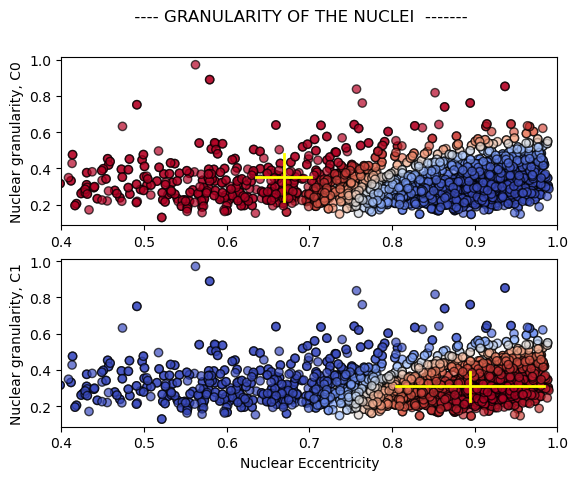

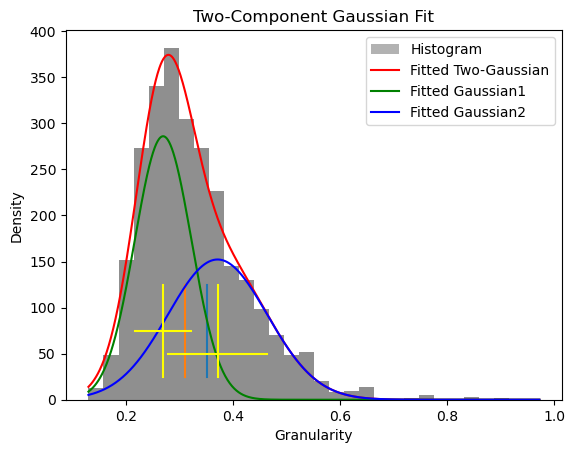

GRanul0: 0.27  +/- 0.05
GRanul1: 0.37  +/- 0.09
total number of cell type read: 15
total number of cell type read: 13
0.67 0.13 0.89 0.06


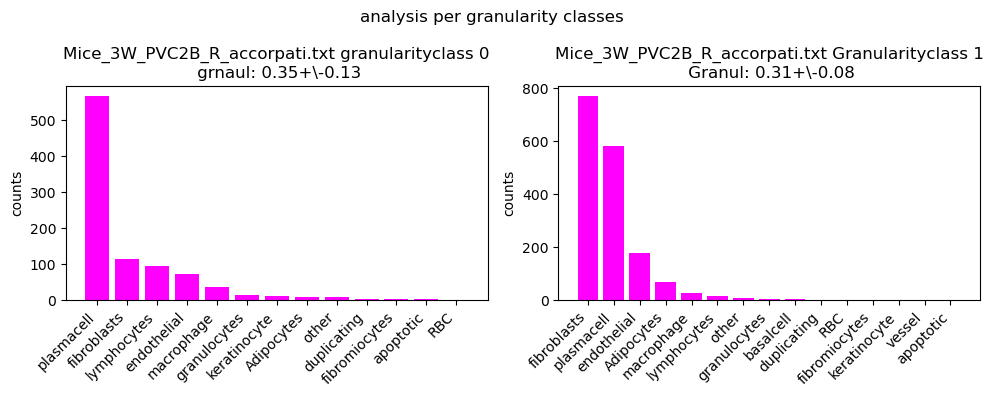

In [8]:
'''
######################### GRANULARITY ANALYSIS ---- ###########################

"Nucleus:Perimeter": "float64",            #0
    "Nucleus:Eccentricity": "float64",         #1
    "Cell:Perimeter": "float64",               #2
    "Cell:Eccentricity": "float64",            #3
    "Nucleus:HematoxyAverage": "float64",      #4
    "Nucleus:HematoxyStd": "float64",          #5
    "Cytop:EosinAverage": "float64",           #6
    "Cytop:EosinStd": "float64",               #7


    GRANULARITY ANALYSIS ---- 
'''
NucHemaAve = np.asarray(df.values[:,4]      , dtype=np.float64) 
NucHemaStd = np.asarray(df.values[:,5]      , dtype=np.float64) 
CytoEosAve = np.asarray(df.values[:,6]      , dtype=np.float64) 
CytoEosStd = np.asarray(df.values[:,7]      , dtype=np.float64) 

NucEcc      = np.asarray(df.values[:,1]      , dtype=np.float64)
NucGranul   = NucHemaStd/NucHemaAve
CytoGranul  = CytoEosStd/CytoEosAve

print ('#### now use GAUSSIAN MIXTURE MODEL           Gauss Mix Model ################')

data                = np.column_stack((NucEcc,NucGranul)) 
colors_GM, probaG, indices_classG_0,indices_classG_1,numeric_labels =  GaussianMixModel(data)
#colors_GM, proba, indices_class_0,indices_class_1,indices_class_2,numeric_labels =  GaussianMixModel3comp(data)

###### averages ###########################

Granul0_ave = round(NucGranul[indices_classG_0].mean(),2)
Granul1_ave = round(NucGranul[indices_classG_1].mean(),2)
#Granul2_ave = NucGranul[indices_class_2].mean()
Granul0_std = round(NucGranul[indices_classG_0].std(),2)
Granul1_std = round(NucGranul[indices_classG_1].std(),2)
#Granul2_std = NucGranul[indices_class_2].std()

NucEcc0_ave = NucEcc[indices_classG_0].mean()
NucEcc1_ave = NucEcc[indices_classG_1].mean()
#NucEcc2_ave = NucEcc[indices_class_2].mean()

print ( '   NucEcc0_ave  ,  Granul_ave  ,  Granul0_std')
print ( np.round(NucEcc0_ave,2) , np.round(Granul0_ave,2),np.round(Granul0_std,2))
print ( np.round(NucEcc1_ave,2) , np.round(Granul1_ave,2),np.round(Granul1_std,2))
#print ( np.round(NucEcc2_ave,2) , np.round(Granul2_ave,2),np.round(Granul2_std,2))


########  plots ###########################

#F,A = plt.subplots(3,1)
F,A = plt.subplots(2,1)

A[0].scatter(NucEcc,(NucGranul), marker = 'o',
     c = probaG[:, 0], 
     cmap='coolwarm', 
     edgecolors="k", 
     alpha=0.7)
A[0].plot([NucEcc0_ave,NucEcc0_ave],[Granul0_ave-Granul0_std,Granul0_ave+Granul0_std],linewidth=2,color='yellow')
A[0].plot([NucEcc0_ave*0.95,NucEcc0_ave*1.05],[Granul0_ave,Granul0_ave],linewidth=2,color='yellow')
A[0].set_ylabel('Nuclear granularity, C0')

A[1].scatter(NucEcc,(NucGranul), marker = 'o',
     c = probaG[:, 1], 
     cmap='coolwarm', 
     edgecolors="k", 
     alpha=0.7)
A[1].plot([NucEcc1_ave,NucEcc1_ave],[Granul1_ave-Granul1_std,Granul1_ave+Granul1_std],linewidth=2,color='yellow')
A[1].plot([NucEcc1_ave*0.9,NucEcc1_ave*1.1],[Granul1_ave,Granul1_ave],linewidth=2,color='yellow')

A[1].set_xlabel('Nuclear Eccentricity')
A[1].set_ylabel('Nuclear granularity, C1')

for k in range(2):
    A[k].set_xlim(0.4,1)

plt.suptitle(' ---- GRANULARITY OF THE NUCLEI  ------- ')

plt.figure()
plt.hist((NucGranul), bins=30, color="gray", alpha=0.7)
plt.plot([Granul0_ave,Granul0_ave],[25,125])
plt.plot([Granul1_ave,Granul1_ave],[25,125])
plt.xlabel(' Nucleus granularity')

###        DUMP TO TWO CLASSES IOF GRANULARITY 
####       THE CLASS 1 AND 2 ARE PUT ON A SINGLE CLASS
########## saving ###########################
df_out      = pd.DataFrame({'Necc': NucEcc, 'Granul': NucGranul, 'proba0': probaG[:,0], 'proba1': probaG[:,1],'GRanul.class': numeric_labels, 'ImageID':df.values[:,9]})
# Save to a CSV file
Fout        = prenome + '_NuclGranulAnalysis.csv'
df_out.to_csv(path+Fout, index=False)
print("-------- File " + Fout + " has been created !!!!")
print ('Main output is the varialble NuclGRanularity')

########################   fitting of the histogram  of the granularity 
from scipy.optimize import curve_fit

# Define a two-component Gaussian function
def two_gaussian(x, mu1, sigma1, A1, mu2, sigma2, A2):
    gauss1 = A1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2))
    gauss2 = A2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2))
    return gauss1 + gauss2

# Generate synthetic data for demonstration

def Comp2_Hist_Fit(data,bins=30):
# Create a histogram
#bins = 30
    hist, bin_edges = np.histogram(data, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit the histogram with the two-component Gaussian function
    initial_guess = [0.3, 0.1, 200, 0.5, 0.2, 100]  # Initial guesses for [mu1, sigma1, A1, mu2, sigma2, A2]
    params, _ = curve_fit(two_gaussian, bin_centers, hist, p0=initial_guess)

    pars1  = np.copy(params)
    pars1[3:] = [0,1,0]
    pars2  = np.copy(params)
    pars2[0:3] = [0,1,0]

# Plot the results
    xfit  = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    hfit  = two_gaussian(xfit, *params)
    hfit1 = two_gaussian(xfit, *pars1)
    hfit2 = two_gaussian(xfit, *pars2)

    return params,xfit,hfit,hfit1,hfit2

bins = 30
params,xfit,hfit,hfit1,hfit2 = Comp2_Hist_Fit(NucGranul,bins)

plt.hist(NucGranul, bins=bins, alpha=0.6, color='gray', label='Histogram')

plt.plot(xfit, hfit, label='Fitted Two-Gaussian', color='red')
plt.plot(xfit, hfit1, label='Fitted Gaussian1', color='green')
plt.plot(xfit, hfit2, label='Fitted Gaussian2', color='blue')


plt.plot([params[0],params[0]],[25,125],c='yellow')
plt.plot([params[0]-params[1],params[0]+params[1]],[75,75],c='yellow')
plt.plot([params[3],params[3]],[25,125],c='yellow')
plt.plot([params[3]-params[4],params[3]+params[4]],[50,50],c='yellow')

plt.legend()
plt.xlabel('Granularity')
plt.ylabel('Density')
plt.title('Two-Component Gaussian Fit')
plt.show()

print ('GRanul0:',round(params[0],2),' +/-' , round(params[1],2))
print ('GRanul1:',round(params[3],2),' +/-' , round(params[4],2))

####   which types are the cells with the two classes of granularioty ? 
######################### analaysis per eccentricity classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analysis per granularity classes ')

sorted_df = GetSubsetClass(Urdf,indices_classG_1)
iframe = 1
A1[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
A1[iframe].set_title(Urname+' Granularityclass ' + str(iframe) + '\n Granul: ' + str(Granul1_ave)+'+\-'+str(Granul1_std))

sorted_df = GetSubsetClass(Urdf,indices_classG_0)
iframe = 0
A1[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
A1[iframe].set_title(Urname+' granularityclass '+str(iframe)+ '\n grnaul: ' + str(Granul0_ave)+'+\-'+str(Granul0_std))
plt.tight_layout()

##############compute Nucleus Eccentricity ont he two classes

Necc_granul0_ave = round(NEcc[indices_classG_0].mean(),2)
Necc_granul0_std = round(NEcc[indices_classG_0].std(),2)
Necc_granul1_ave = round(NEcc[indices_classG_1].mean(),2)
Necc_granul1_std = round(NEcc[indices_classG_1].std(),2)
print (Necc_granul0_ave,Necc_granul0_std,Necc_granul1_ave,Necc_granul1_std)
#A1[0].text(6,250,'Nuc.Ecc.='+ str(Necc_granul0_ave)+'+/-'+str(Necc_granul0_std))

#A1[1].text(6,250,'Nuc.Ecc.='+ str(Necc_granul1_ave)+'+/-'+str(Necc_granul1_std))



total number of cell type read: 15
G1 
         types  counts
1  plasmacell     581
total number of cell type read: 13
G0 
         types  counts
0  plasmacell     567
---------------------------------------------
 
--------- feature defijntion step 1: sorted df, class0, Eccentricity: [1.37, 0.04]
len : 13
------------------  feature defintion step 1: sorted df, class1, Fractality: [1.33, 0.06]
len : 15
 ---- THE FINAL STEP : checking for the largest in-class occurence ----
0 884 fibroblasts 1 87.10407239819004 0.10423480159152622 12.895927601809955 87.10407239819004
1 1148 plasmacell 1 50.609756097560975 0.14595805421131 49.390243902439025 50.609756097560975
2 254 endothelial 1 70.86614173228347 0.09640742176266398 29.133858267716537 70.86614173228347
3 79 Adipocytes 1 86.07594936708861 0.11100626943245218 13.924050632911392 86.07594936708861
4 113 lymphocytes 0 84.95575221238938 0.9823893989140835 84.95575221238938 15.044247787610619
5 65 macrophage 0 58.46153846153846 0.946850819950

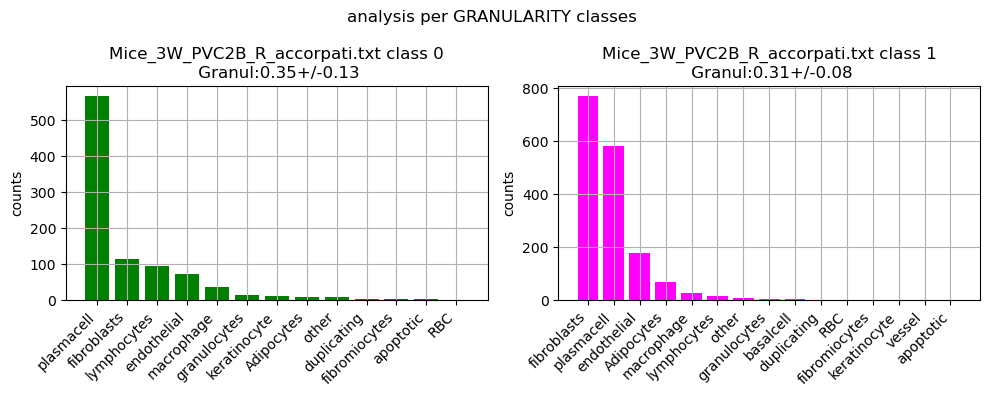

In [9]:
############ THIS IS THE PART OF THE CODE WHERE I GET THE MAJOR FEATURES ON THE GRANULARITY AND ASSIGN IT TO THE MOST 
#### INFLUENCING CELLS


######################### analaysis per GRANUlariTY classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analysis per GRANULARITY classes ')

#### create the sorted subsets 
sorted_df_G1 = GetSubsetClass(Urdf,indices_classG_1)
print ("G1 \n", sorted_df_G1[sorted_df_G1["types"] == 'plasmacell'])

iframe = 1
A1[iframe].bar(sorted_df_G1['types'] ,sorted_df_G1['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df_G1['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class ' + str(iframe))
A1[iframe].grid()

#### create the sorted subsets 
sorted_df_G0 = GetSubsetClass(Urdf,indices_classG_0)
print ("G0 \n", sorted_df_G0[sorted_df_G0["types"] == 'plasmacell'])


iframe = 0
A1[iframe].bar(sorted_df_G0['types'] ,sorted_df_G0['counts'],color='green')
A1[iframe].set_xticklabels(sorted_df_G0['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class '+str(iframe))
A1[iframe].grid()


### evaluation of the average eccentricity per type of cells and average probability
## colors_GM, proba, indices_class_0,indices_class_1,numeric_labels =  GaussianMixModel(data)
### we do it over class0
### let's say that we look at the first 3 most populated classes
### sorted_Df0 anjd sorted_df1 are the dataframes with the class0 and class 1 ordered

print ('---------------------------------------------\n ')
Granul_ave0 = [np.round(Granul0_ave,3),np.round(Granul0_std,3)]
A1[0].set_title(Urname+' class '+str(0)+'\n Granul:'+str(Granul_ave0[0])+'+/-'+str(Granul_ave0[1]))

print('--------- feature defijntion step 1: sorted df, class0, Eccentricity:', Fract_ave0)

#### these are dataframes with the probabilities of belongin to a class.
Urcell = "fibroblasts"
df_res0_G = Create_dfRes(sorted_df_G0, Urdf, indices_classG_0,probaG)

Granul_ave1 = [np.round(Granul1_ave,3),np.round(Granul1_std,3)]
A1[1].set_title(Urname+' class '+str(1)+'\n Granul:'+str(Granul_ave1[0])+'+/-'+str(Granul_ave1[1]))
print ('------------------  feature defintion step 1: sorted df, class1, Fractality:', Fract_ave1)

df_res1_G = Create_dfRes(sorted_df_G1, Urdf, indices_classG_1,probaG)

print (" ---- THE FINAL STEP : checking for the largest in-class occurence ----")
#### search each of the uniques entries for the largest belonging probability and then select the corresponding class0 probability

df_FEATURES_G = Create_FEATURES(dfCellsTypes,df_res0_G,df_res1_G)

df_Classification_G =   pd.DataFrame(columns=["Type","Class", "ProbGranul_Avg", "ProbGranul_Std"])  

Thr_App   = 45   ####   percentage of the data belonging to the KDE class  
Thr_Count = 45   ####   absolute number of cells in the specific class 
for k in range(len(df_FEATURES_G)):
    U = df_FEATURES_G.iloc[k]["Type"]
    C0 = dfCellsTypes[dfCellsTypes['types'] == df_FEATURES_G.iloc[k]["Type"]]['counts'].values[0]
    
    filtered_df_res = df_res0_G[df_res0_G['Type'] == U]["ProbApp (%)"]
    if not filtered_df_res.empty:
        prob_App_class0 = filtered_df_res.values[0]

    filtered_df_res = df_res1_G[df_res1_G['Type'] == U]["ProbApp (%)"]
    if not filtered_df_res.empty:
        prob_App_class1 = filtered_df_res.values[0]

#    print(U,C0,df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["Class"] )
    if df_FEATURES_G.iloc[k]["ProbAppEcc (%)"] > Thr_App and C0 > Thr_Count:
        print (k,C0,df_FEATURES_G.iloc[k]["Type"],df_FEATURES_G.iloc[k]["Class"],df_FEATURES_G.iloc[k]["ProbAppEcc (%)"],df_FEATURES_G.iloc[k]["ProbEcc_Avg"],
               prob_App_class0 ,prob_App_class1 )
        df_Classification_G.loc[len(df_Classification_G)] = [
                U,
                df_FEATURES_G.iloc[k]["Class"],
                df_FEATURES_G.iloc[k]["ProbEcc_Avg"],
                df_FEATURES_G.iloc[k]["ProbEcc_Std"]/np.sqrt(df_FEATURES_G.iloc[k]["Ncells"])
                 
            ]

print (df_Classification_G)

plt.tight_layout()

analysis of x=Log(area_nucelus) vs y = Log(area cells)
mom[ 0 ]= 25817.24
mom[ 1 ]= 0.58
mom[ 2 ]= 0.74
mom[ 3 ]= 0.43
mom[ 4 ]= 0.34
mom[ 5 ]= 0.55
classification by threshold: x**2 + y**2 > 30
number of elements in classa A: 1529
number of elements in classa B: 1092
-------- File Mice_3W_PVC2B_R_accorpati_LabelAreaRatio.csv has been created !!!!
 Area ratio --- : A0= 1.46 +/- 0.19 
 ----------- A1= 1.47  +/-  0.18
T-statistic two classes of  Nucleus Area: -41.61436640891595
P-value: 5.040795200009201e-284
T-statistic two classes of CELL Area: -67.78452294484262
P-value: 0.0
KDE: class 0 items: 945
KDE: class 1 items: 1676
<Nuclear eccentricity over Area Class 0> =  0.771 +/- 0.005
<Nuclear eccentricity over Area Class 1> =  0.84 +/- 0.0
T-statistic Ecc. Nucleus over the two Area classes : -51.055432717601114
P-value: 0.0
[87.36688449 87.36688381 87.36688314 87.36688246 87.36688178 87.36688111
 87.36688043 87.36687975 87.36687908 87.3668784  87.36687772 87.36687705
 87.36687637 87.366

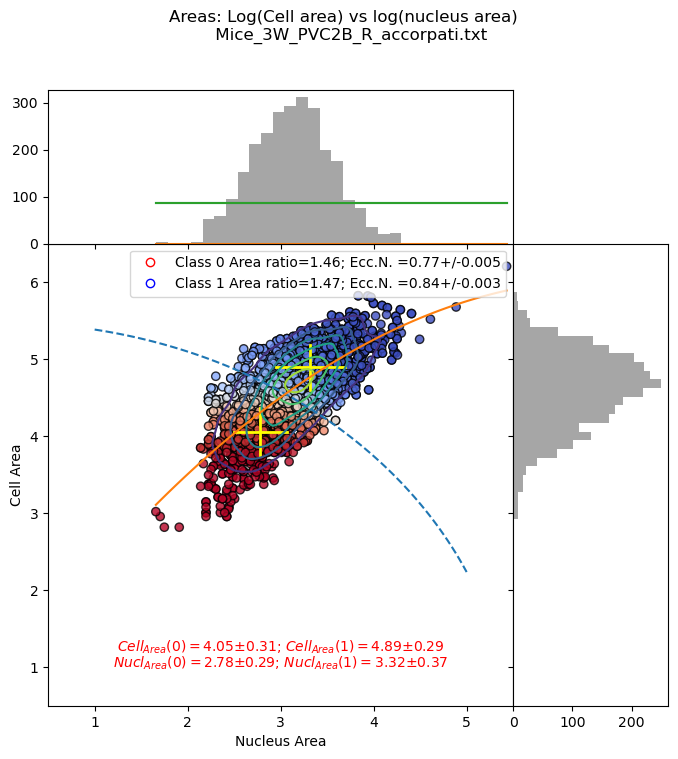

total number of cell type read: 14
total number of cell type read: 15


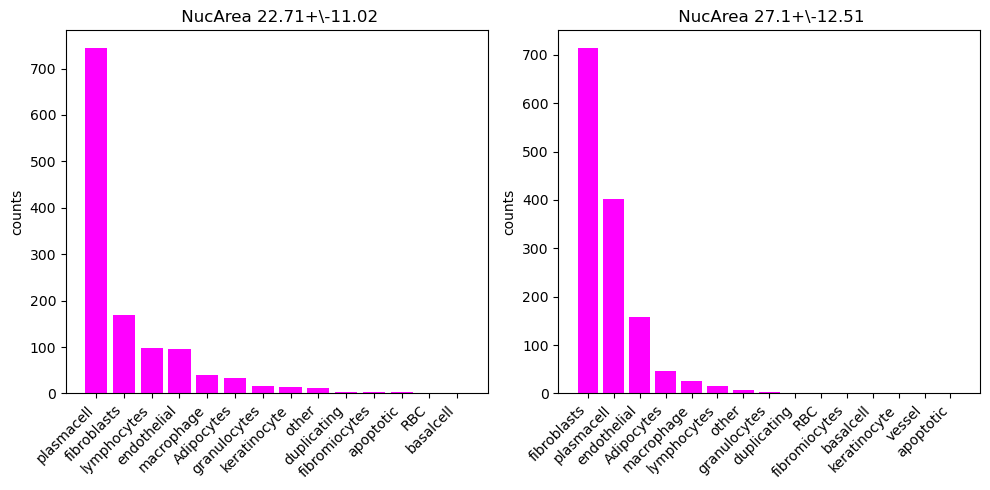

In [10]:
#############          333333333333333333333333333333333333    #####################
#####################             THIRD PART                   ##################
############################## area ratios and eccentricity  ######################
#############################   LOG LOG    #######################################

import seaborn as sns
from scipy.stats import ttest_ind
from IPython.display import display, Math


###################     CONVERT THE AREAS IN LOG SCALE FOR THE ANALYSIS


X       =   dfAreas.values[:,0]
xL      =   dfAreas.columns[0]
Y       =   dfAreas.values[:,1]
yL      =   dfAreas.columns[1]
######## force type 64
X = np.asarray(X, dtype=np.float64)
Y = np.asarray(Y, dtype=np.float64)

# Create figure with gridspec
fig = plt.figure(figsize=(8, 8))
grid = fig.add_gridspec(4, 4, hspace=0, wspace=0)
##############  CHANGE TO LOGARITHM
x       = np.log(X)
y       =  np.log(Y)

# Create axes
ax_main  = fig.add_subplot(grid[1:4, 0:3])  # Main contour plot
ax_xhist = fig.add_subplot(grid[0, 0:3], sharex=ax_main)  # Top histogram
ax_yhist = fig.add_subplot(grid[1:4, 3], sharey=ax_main)  # Right histogram

# Remove ticks for better aesthetics
ax_xhist.tick_params(axis="x", labelbottom=False)
ax_yhist.tick_params(axis="y", labelleft=False)


##################### first try a 2D gaussian fit   OLD   ###############
R = 0.1 
params_initial = [2, 0.6, 0.6, 0.4, 0.5, 0.001, -0.001, 2, 0.75, 0.75, 0.5, 0.5, +0.005, 0.008]
grid_x,grid_y,density_matrix,params_opt = Compute_density(x,y,R,params_initial)
##### try fitting with Gaussians 
#print ('--- NOW fitting nthe density matrices')
print ('analysis of x=Log(area_nucelus) vs y = Log(area cells)')
#print ('Best fit params 1: ',popt[0:7])
#print ('Best fit params 2: ',popt[7:])

############   COMPUTE MOMENTS OF THE DISTRIBUTION
moms    = compute_moments(grid_x,grid_y,density_matrix)
k=0
for mx in moms:
    print ('mom[',k,']=',round(mx,2))
    k = k +1
# Define MANUAL classification rules for 2 classes
Rth        = 30
classes = np.where((x**2 + y**2 > Rth), "Class A",  "Class B")    #### these are the classes of the monocytes and othercells
print ('classification by threshold: x**2 + y**2 >',Rth)
print ('number of elements in classa A:',np.sum(classes =='Class A'))
print ('number of elements in classa B:',np.sum(classes =='Class B'))

# Define unique colors per class
color_map = {"Class A": "red", "Class B": "blue", "Class C": "green"}
colors = [color_map[label] for label in classes]
############################   THIS IS THE RIGHT CLASSIFICATION ###########################
########################   USE KDE  FOR CLUSTERING -- NEW and good
data                = np.column_stack((x, y))  # Shape (200, 2)
colors_GM, probAreas,indices_classLogA_0,indices_classLogA_1,numeric_labels =  GaussianMixModel(data)
GX,GY,densityMat_area = ComputeDensityMatrixKDE(x,y)
########################   USE KDE  FOR CLUSTERING -- NEW and good

df_out      = pd.DataFrame({'x': X, 'y': Y, 'label': numeric_labels, 'prob0': probAreas[:,0]})
# Save to a CSV file
Fout        = prenome + '_LabelAreaRatio.csv'
df_out.to_csv(path+Fout, index=False)
print("-------- File " + Fout + " has been created !!!!")


x1a                 = np.mean(x[indices_classLogA_0])  ##Nucleus area
LogArea_class0      = x1a
x1s                 = np.std(x[indices_classLogA_0])
x2a                 = np.mean(x[indices_classLogA_1])
LogArea_class1      = x2a
x2s                 = np.std(x[indices_classLogA_1])
y1a                 = np.mean(y[indices_classLogA_0]) ## cell area
y1s                 = np.std(y[indices_classLogA_0])
y2a                 = np.mean(y[indices_classLogA_1])
y2s                 = np.std(y[indices_classLogA_1])
mdig        = 2
StatInfo =  r'$Nucl_{Area}(0)=$' + str(round(x1a,mdig)) + '$\pm$'+str(round(x1s,mdig)) + '; $Nucl_{Area}(1)=$' + str(round(x2a,2)) + '$\pm$'+str(round(x2s,2))
StatInfo2 = r'$Cell_{Area}(0)=$' + str(round(y1a,mdig)) + '$\pm$'+str(round(y1s,mdig)) + '; $Cell_{Area}(1)=$' + str(round(y2a,2)) + '$\pm$'+str(round(y2s,2))

##### ratios
Ratio1      = y1a/x1a
Ratio1S     = np.sqrt( (y1s/x1a)**2 + (y1a*x1s/x1a**2)**2)
##### ratios
Ratio2      = y2a/x2a
Ratio2S     = np.sqrt( (y2s/x2a)**2 + (y2a*x2s/x2a**2)**2)
print (' Area ratio --- : A0=', np.round(Ratio1,2),'+/-', np.round(Ratio1S,2), '\n ----------- A1=',np.round(Ratio2,2), ' +/- ',np.round(Ratio2S,2))

##### ratios
t_statistic, p_value = ttest_ind(x[indices_classLogA_0], x[indices_classLogA_1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
print("T-statistic two classes of  Nucleus Area:", t_statistic)
print("P-value:", p_value)
t_statistic, p_value = ttest_ind(y[indices_classLogA_0], y[indices_classLogA_1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
print("T-statistic two classes of CELL Area:", t_statistic)
print("P-value:", p_value)


xG,yG,densityMat_kde= ComputeDensityMatrixKDE(x,y)
threshold           = 0.6  # Define minimum confidence level
labels              = (probAreas[:, 0] > threshold).astype(int)  # Assign based on probability
###############################################################################################


##### OK now get the indices of the class A and B
#print("Indices of class 0:", indices_class_0)
#print("Indices of class 1:", indices_class_1)
##### COMPUTE eCCENTRICITY ON THE CLASSESS
EccClass1       = NEcc[indices_classLogA_0].mean()
EccClass1Std    = NEcc[indices_classLogA_0].std()/np.sqrt(indices_classLogA_0.size)

EccClass2       = NEcc[indices_classLogA_1].mean()
EccClass2Std    = NEcc[indices_classLogA_1].std()/np.sqrt(indices_classLogA_1.size)  

print ('KDE: class 0 items:',indices_classLogA_0.size)
print ('KDE: class 1 items:',indices_classLogA_1.size)


# Perform t-test

print ('<Nuclear eccentricity over Area Class 0> = ',round(EccClass1,3),'+/-',round(EccClass1Std,3) )
str0 = 'Area ratio='+str(np.round(Ratio1,2))+'; Ecc.N. =' + str(round(EccClass1,2)) + '+/-' +str(round(EccClass1Std,3))
print ('<Nuclear eccentricity over Area Class 1> = ',round(EccClass2,2),'+/-',round(EccClass2Std,2) )
str1 = 'Area ratio='+str(np.round(Ratio2,2))+'; Ecc.N. =' + str(round(EccClass2,2)) + '+/-' + str(round(EccClass2Std,3))

pippo0  = np.asarray(NEcc[indices_class_0], dtype=np.float64)
pippo1  = np.asarray(NEcc[indices_class_1], dtype=np.float64)

#t_statistic, p_value = ttest_ind(NEcc[indices_class_0], NEcc[indices_class_1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
t_statistic, p_value = ttest_ind(pippo0, pippo1, equal_var=False)  # Set `equal_var=False` for Welch’s t-test

print("T-statistic Ecc. Nucleus over the two Area classes :", t_statistic)
print("P-value:", p_value)

### now display results for KDE

ax_main.plot([x1a,x1a],[y1a-y1s,y1a+y1s],color='yellow',linewidth = 2)
ax_main.plot([x1a-x1s,x1a+x1s],[y1a,y1a],color='yellow',linewidth = 2)
ax_main.plot([x2a,x2a],[y2a-y2s,y2a+y2s],color='yellow',linewidth = 2)
ax_main.plot([x2a-x2s,x2a+x2s],[y2a,y2a],color='yellow',linewidth = 2)


ax_main.set_xlim(0.5,5.5)
ax_main.set_ylim(0.5,6.5)
ax_main.set_ylabel(yL)
ax_main.set_xlabel(xL)
#ax_main.contour(xG,yG,densityMat_kde,alpha=0.5)
i03         = ax_main.scatter(x, y, c=probAreas[:, 0], cmap='coolwarm', edgecolors="k", alpha=0.8)  # class 0
ax_main.contour(xG,yG,densityMat_kde)
#cbar1       = plt.colorbar(i03,ax=ax_main,shrink=0.4)
#cbar1.set_label('prob. class 0')
csic    = np.linspace(1,5,100)
ax_main.plot(csic,np.sqrt(Rth - csic**2),'--')
# Fit a 2nd-degree polynomial (parabola)
coeffs = np.polyfit(x, y, 2)
parabola = np.poly1d(coeffs)

# Generate smooth curve for plotting
x_fit = np.linspace(min(x), max(x), 100)
yP_fit = parabola(x_fit)
ax_main.plot(x_fit, yP_fit, label=f'Fit: {coeffs[0]:.2f}x**2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f} ')


ax_main.text(3., 1., StatInfo, fontsize=10, color="red", ha="center")
ax_main.text(3., 1.2, StatInfo2, fontsize=10, color="red", ha="center")


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='red', markersize=6, label='Class 0 '+str0),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='blue', markersize=6, label='Class 1 '+str1)
]
# Add legend to the main panel
ax_main.legend(handles=legend_elements, loc='upper right')


# Plot histograms aligned with axes
bins = 30
ax_xhist.hist(x, bins=bins, color="gray", alpha=0.7)

params,xfit,hfit,hfit1,hfit2 = Comp2_Hist_Fit(x,bins)
ax_xhist.plot(xfit,hfit)
ax_xhist.plot(xfit,hfit1)
ax_xhist.plot(xfit,hfit2)
print (hfit)

ax_yhist.hist(y, bins=30, color="gray", alpha=0.7, orientation="horizontal")

plt.suptitle('Areas: Log(Cell area) vs log(nucleus area)  \n '+nome)
plt.show()

###### nopw plot also the distributiuons of the eccentricity
F,A = plt.subplots(1,2,figsize=(10,5))

subset = Urdf.loc[indices_class_0]
aveNucArea_class0 = round(subset['Nucleus:Area'].mean(),2)
stdNucArea_class0 = round(subset['Nucleus:Area'].std(),2)

iframe = 0
sorted_df = GetSubsetClass(Urdf,indices_class_0)
A[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A[iframe].set_xticklabels(sorted_df['types'],size=10,rotation = 45,ha='right')
A[iframe].set_ylabel('counts')
A[iframe].set_title(' NucArea '+ str(aveNucArea_class0)+'+\-'+str(stdNucArea_class0))

subset = Urdf.loc[indices_class_1]
aveNucArea_class1 = round(subset['Nucleus:Area'].mean(),2)
stdNucArea_class1 = round(subset['Nucleus:Area'].std(),2)

iframe = 1
sorted_df = GetSubsetClass(Urdf,indices_class_1)
A[iframe].bar(sorted_df['types'] ,sorted_df['counts'],color='magenta')
A[iframe].set_xticklabels(sorted_df['types'],size=10,rotation = 45,ha='right')
A[iframe].set_ylabel('counts')
A[iframe].set_title(' NucArea '+ str(aveNucArea_class1)+'+\-'+str(stdNucArea_class1))

plt.tight_layout()





total number of cell type read: 13
total number of cell type read: 13
---------------------------------------------
 
--------- feature defijntion step 1: sorted df, class0, LogARea: 2.782
len : 13
------------------  feature defintion step 1: sorted df, class1, LogArea: 3.321
len : 13
 ---- THE FINAL STEP : checking for the largest in-class occurence ----
0 884 fibroblasts 1 73.75565610859728 0.16594644419590254 26.2 73.8
1 1148 plasmacell 1 59.75609756097561 0.17945801178094192 40.2 59.8
2 254 endothelial 1 57.874015748031496 0.23059602232188112 42.1 57.9
3 79 Adipocytes 1 91.13924050632912 0.1271120404300809 8.9 91.1
4 113 lymphocytes 0 60.176991150442475 0.8889292503630727 60.2 39.8
5 65 macrophage 1 61.53846153846154 0.13962523626874765 38.5 61.5
          Type  Class  ProbLogArea_Avg  ProbLogArea_Std
0  fibroblasts      1         0.165946         0.000196
1   plasmacell      1         0.179458         0.000201
2  endothelial      1         0.230596         0.001028
3   Adipocytes

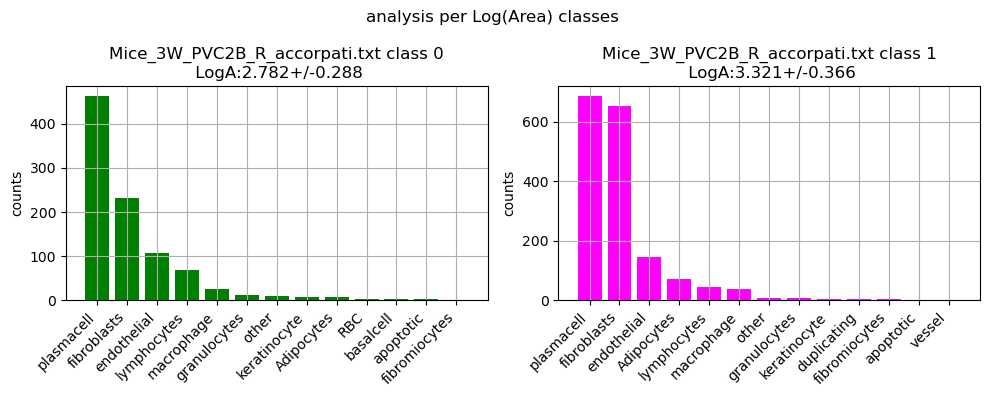

In [11]:
############ THIS IS THE PART OF THE CODE WHERE I GET THE MAJOR FEATURES
# ##########  ON THE AREA of the nuclei AND ASSIGN IT TO THE MOST 
#### INFLUENCING/ED CELLS


######################### analaysis per GRANUlariTY classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analysis per Log(Area) classes ')

#### create the sorted subsets 

#probAreas,

sorted_df_LogA1 = GetSubsetClass(Urdf,indices_classLogA_1)

iframe = 1
A1[iframe].bar(sorted_df_LogA1['types'] ,sorted_df_LogA1['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df_LogA1['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class ' + str(iframe))
A1[iframe].grid()

#### create the sorted subsets 
sorted_df_LogA0 = GetSubsetClass(Urdf,indices_classLogA_0)

iframe = 0
A1[iframe].bar(sorted_df_LogA0['types'] ,sorted_df_LogA0['counts'],color='green')
A1[iframe].set_xticklabels(sorted_df_LogA0['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class '+str(iframe))
A1[iframe].grid()


### evaluation of the average eccentricity per type of cells and average probability
## colors_GM, proba, indices_class_0,indices_class_1,numeric_labels =  GaussianMixModel(data)
### we do it over class0
### let's say that we look at the first 3 most populated classes
### sorted_Df0 anjd sorted_df1 are the dataframes with the class0 and class 1 ordered

print ('---------------------------------------------\n ')
LogA_ave0 = [np.round(x1a,3),np.round(x1s,3)]
A1[0].set_title(Urname+' class '+str(0)+'\n LogA:'+str(LogA_ave0[0])+'+/-'+str(LogA_ave0[1]))

print('--------- feature defijntion step 1: sorted df, class0, LogARea:', np.round(x1a,3))

#### these are dataframes with the probabilities of belongin to a class.
df_res0_LogA = Create_dfRes(sorted_df_LogA0, Urdf, indices_classLogA_0,probAreas)

LogA_ave1 = [np.round(x2a,3),np.round(x2s,3)]
A1[1].set_title(Urname+' class '+str(1)+'\n LogA:'+str(LogA_ave1[0])+'+/-'+str(LogA_ave1[1]))
print ('------------------  feature defintion step 1: sorted df, class1, LogArea:', np.round(x2a,3))

df_res1_LogA = Create_dfRes(sorted_df_LogA1, Urdf, indices_classLogA_1,probAreas)
print (" ---- THE FINAL STEP : checking for the largest in-class occurence ----")
#### search each of the uniques entries for the largest belonging probability and then select the corresponding class0 probability

df_FEATURES_Area = Create_FEATURES(dfCellsTypes,df_res0_LogA,df_res1_LogA)

df_Classification_LogArea =   pd.DataFrame(columns=["Type","Class", "ProbLogArea_Avg", "ProbLogArea_Std"])  

Thr_App   = 45
Thr_Count = 30
for k in range(len(df_FEATURES_Area)):
    U = df_FEATURES_Area.iloc[k]["Type"]
    ##### numnber of cells in the 2 classes 
    filtered_df_res = df_res0_LogA[df_res0_LogA['Type'] == U]["ProbApp (%)"]
    if not filtered_df_res.empty:
        prob_App_class0 = filtered_df_res.values[0]

    filtered_df_res = df_res1_LogA[df_res1_LogA['Type'] == U]["ProbApp (%)"]
    if not filtered_df_res.empty:
        prob_App_class1 = filtered_df_res.values[0]

    C0 = dfCellsTypes[dfCellsTypes['types'] == df_FEATURES_Area.iloc[k]["Type"]]['counts'].values[0]
    #print(U,C0,df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["Class"] )
    if df_FEATURES_Area.iloc[k]["ProbAppEcc (%)"] > Thr_App and C0 >Thr_Count:
        print (k,C0,df_FEATURES_Area.iloc[k]["Type"],df_FEATURES_Area.iloc[k]["Class"],df_FEATURES_Area.iloc[k]["ProbAppEcc (%)"],
               df_FEATURES_Area.iloc[k]["ProbEcc_Avg"],np.round(prob_App_class0,1),np.round(prob_App_class1,1))
        df_Classification_LogArea.loc[len(df_Classification_LogArea)] = [
                U,
                df_FEATURES_Area.iloc[k]["Class"],
                df_FEATURES_Area.iloc[k]["ProbEcc_Avg"],
                df_FEATURES_Area.iloc[k]["ProbEcc_Std"]/np.sqrt(df_FEATURES_Area.iloc[k]["Ncells"])
                 
            ]

print (df_Classification_LogArea)

plt.tight_layout()

In [12]:
#print (df_Classification_LogArea.iloc[0])
#print (df_Classification_F)
#print (df_Classification_G)
#print (dfCellsTypes)

df_U_Classification =   pd.DataFrame(
    columns=["Type",
            "ClassE",
            "ProbEcc_Avg",
            "ProbEcc_Std",
            "ClassFract",
            "ProbFrac_Avg",
            "ProbFrac_Std",
            "ClassGranul",
            "ProbGranul_Avg",
            "ProbGranul_Std",
            "ClassLogArea",
            "ProbLogArea_Avg",
            "ProbLogArea_Std"]
            )  

for  U  in dfCellsTypes["types"]:

    U_slice_E = df_Classification_E[ df_Classification_E["Type"]==U ]
    U_slice_F = df_Classification_F[ df_Classification_F["Type"]==U ]
    U_slice_G = df_Classification_G[ df_Classification_G["Type"]==U ]
    U_slice_L = df_Classification_LogArea[ df_Classification_LogArea["Type"]==U ]
    
    empty_count = sum([
        U_slice_E.empty,
        U_slice_F.empty,
        U_slice_G.empty,
        U_slice_L.empty
    ])
    #print (U,'e:',empty_count)
    
    if empty_count <= 1:
        df_U_Classification.loc[len(df_U_Classification)] = [
            U_slice_E["Type"].values[0] if not U_slice_E.empty else -1,
            U_slice_E["Class"].values[0] if not U_slice_E.empty else -1,
            U_slice_E["ProbEcc_Avg"].values[0] if not U_slice_E.empty else -1,
            U_slice_E["ProbEcc_Std"].values[0] if not U_slice_E.empty else -1,

            U_slice_F["Class"].values[0] if not U_slice_F.empty else -1,
            U_slice_F["ProbFrac_Avg"].values[0] if not U_slice_F.empty else -1,
            U_slice_F["ProbFrac_Std"].values[0] if not U_slice_F.empty else -1,

            U_slice_G["Class"].values[0] if not U_slice_G.empty else -1,
            U_slice_G["ProbGranul_Avg"].values[0] if not U_slice_G.empty else -1,
            U_slice_G["ProbGranul_Std"].values[0] if not U_slice_G.empty else -1,

            U_slice_L["Class"].values[0] if not U_slice_L.empty else -1,
            U_slice_L["ProbLogArea_Avg"].values[0] if not U_slice_L.empty else -1,
            U_slice_L["ProbLogArea_Std"].values[0] if not U_slice_L.empty else -1
        ]

    else:
        print (' No results for ',U,empty_count)
    
LLEN =  (len(df_U_Classification))

for k in range(LLEN):

    print ("{:<12} {:<7} {:<7} {:<7} {:<7} {:<7} {:<7}".format(
        df_U_Classification.iloc[k]["Type"],
        df_U_Classification.iloc[k]["ClassE"], round(df_U_Classification.iloc[k]["ProbEcc_Avg"],3),
        df_U_Classification.iloc[k]["ClassFract"], round(df_U_Classification.iloc[k]["ProbFrac_Avg"],3),
        df_U_Classification.iloc[k]["ClassGranul"],
        df_U_Classification.iloc[k]["ClassLogArea"]))




 No results for  granulocytes 4
 No results for  other 4
 No results for  keratinocyte 4
 No results for  duplicating 4
 No results for  RBC 4
 No results for  fibromiocytes 4
 No results for  basalcell 4
 No results for  vessel 4
 No results for  apoptotic 4
fibroblasts  1       0.086   1       0.103   1       1      
plasmacell   0       0.938   0       0.82    1       1      
endothelial  1       0.111   1       0.124   1       1      
Adipocytes   1       0.081   1       0.077   1       1      
lymphocytes  0       0.973   0       0.879   0       0      
macrophage   0       0.972   1       0.092   0       1      


In [14]:
print ((df_U_Classification.iloc[0]["Type"]))

fibroblasts


In [21]:
from scipy.stats import pearsonr

print ('file :',nome)

dataCorr     = np.vstack((proba[:,0],proba[:,1],probAreas[:,0],probAreas[:,1]))

dataCorr2    = {'Eccent.0': proba[:,0],
                'Eccent.1': proba[:,1],
                'Area 0': probAreas[:,0],
                'Area 1': probAreas[:,1]}

df2 = pd.DataFrame(dataCorr2)

# Compute correlation matrix
correlation_matrix = df2.corr(method='pearson')  # or 'spearman'
print('correlation_matrix')
print(correlation_matrix)
'''   
# Compute correlation matrix
correlation_matrix = df.corr(method='pearson')  # or 'spearman'
print('correlation_matrix')
print(correlation_matrix)


# Compute correlation matrix
correlation_matrix = dfAreas.corr(method='pearson')  # or 'spearman'
print('correlation_matrix')
print(correlation_matrix)
'''

file : Mice_3W_PVC2A_newColorDEconv.txt
correlation_matrix
          Eccent.0  Eccent.1    Area 0    Area 1
Eccent.0  1.000000 -1.000000  0.329502 -0.329502
Eccent.1 -1.000000  1.000000 -0.329502  0.329502
Area 0    0.329502 -0.329502  1.000000 -1.000000
Area 1   -0.329502  0.329502 -1.000000  1.000000


"   \n# Compute correlation matrix\ncorrelation_matrix = df.corr(method='pearson')  # or 'spearman'\nprint('correlation_matrix')\nprint(correlation_matrix)\n\n\n# Compute correlation matrix\ncorrelation_matrix = dfAreas.corr(method='pearson')  # or 'spearman'\nprint('correlation_matrix')\nprint(correlation_matrix)\n"

analysis of x=(area_nucelus) vs y = (area cells)
mom[ 0 ]= 10292.28
mom[ 1 ]= 0.11
mom[ 2 ]= 0.22
mom[ 3 ]= 0.03
mom[ 4 ]= 0.01
mom[ 5 ]= 0.06
classification by threshold: x**2 + y**2 > 200
number of elements in classa A: 2621
number of elements in classa B: 0
-------- File Mice_3W_PVC2B_R_accorpati_LabelAreaRatio_LIN.csv has been created !!!!
 Area ratio --- : A0= 4.16 +/- 1.94 
 ----------- A1= 4.74  +/-  2.26


<IPython.core.display.Math object>

T-statistic two classes of  Nucleus Area: -30.024674349688265
P-value: 4.261002948000821e-141
T-statistic two classes of CELL Area: -52.20048475962755
P-value: 5.950345773e-314
KDE: class 0 items: 1781
KDE: class 1 items: 840
<Nuclear eccentricity over Area Class 0> =  0.791 +/- 0.003
<Nuclear eccentricity over Area Class 1> =  0.86 +/- 0.0
<Cell eccentricity over Area Class 0> =  0.704 +/- 0.004
<Cell eccentricity over Area Class 1> =  0.72 +/- 0.0
T-statistic Ecc. Nucleus over the two Area classes : -12.208529555855824
P-value: 4.873031175153699e-33


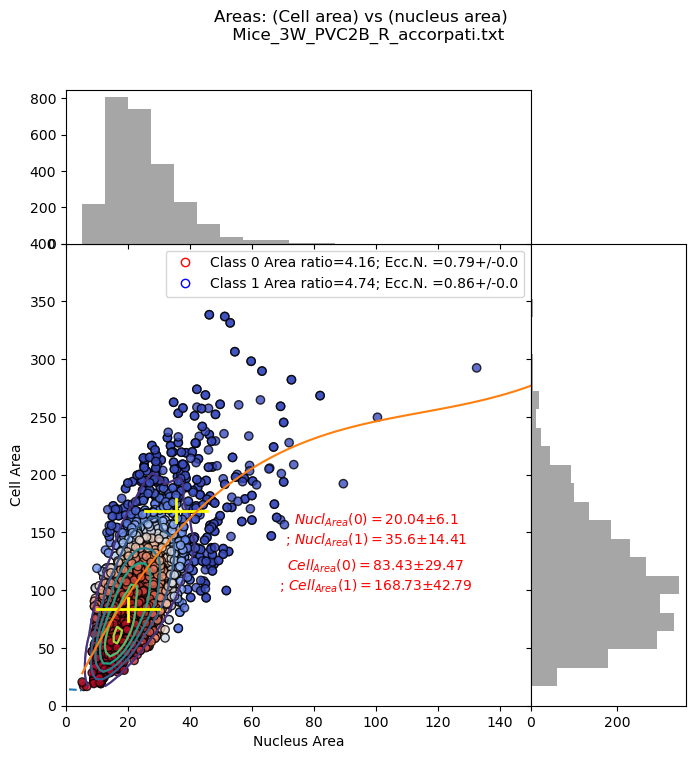

In [13]:
#############          333333333333333333333333333333333333    #####################
#####################             THIRD PART                   ##################
############################## area ratios and eccentricity  ######################
#############################   LIN LIN     #######################################

import seaborn as sns
from scipy.stats import ttest_ind
from IPython.display import display, Math


###################     CONVERT THE AREAS IN LOG SCALE FOR THE ANALYSIS


X       =   dfAreas.values[:,0]
xL      =   dfAreas.columns[0]
Y       =   dfAreas.values[:,1]
yL      =   dfAreas.columns[1]
######## force type 64
X = np.asarray(X, dtype=np.float64)
Y = np.asarray(Y, dtype=np.float64)

# Create figure with gridspec
fig = plt.figure(figsize=(8, 8))
grid = fig.add_gridspec(4, 4, hspace=0, wspace=0)
##############  DO NOT CHANGE TO LOGARITHM
x       = X
y       =  Y

# Create axes
ax_main  = fig.add_subplot(grid[1:4, 0:3])  # Main contour plot
ax_xhist = fig.add_subplot(grid[0, 0:3], sharex=ax_main)  # Top histogram
ax_yhist = fig.add_subplot(grid[1:4, 3], sharey=ax_main)  # Right histogram

# Remove ticks for better aesthetics
ax_xhist.tick_params(axis="x", labelbottom=False)
ax_yhist.tick_params(axis="y", labelleft=False)


##################### first try a 2D gaussian fit   OLD   ###############
R = 0.1 
params_initial = [2, 0.6, 0.6, 0.4, 0.5, 0.001, -0.001, 2, 0.75, 0.75, 0.5, 0.5, +0.005, 0.008]
grid_x,grid_y,density_matrix,params_opt = Compute_density(x,y,R,params_initial)
##### try fitting with Gaussians 
#print ('--- NOW fitting nthe density matrices')
print ('analysis of x=(area_nucelus) vs y = (area cells)')
#print ('Best fit params 1: ',popt[0:7])
#print ('Best fit params 2: ',popt[7:])

############   COMPUTE MOMENTS OF THE DISTRIBUTION
moms    = compute_moments(grid_x,grid_y,density_matrix)
k=0
for mx in moms:
    print ('mom[',k,']=',round(mx,2))
    k = k +1
# Define MANUAL classification rules for 2 classes
Rth        = 200
classes = np.where((x**2 + y**2 > Rth), "Class A",  "Class B")    #### these are the classes of the monocytes and othercells
print ('classification by threshold: x**2 + y**2 >',Rth)
print ('number of elements in classa A:',np.sum(classes =='Class A'))
print ('number of elements in classa B:',np.sum(classes =='Class B'))

# Define unique colors per class
color_map = {"Class A": "red", "Class B": "blue", "Class C": "green"}
colors = [color_map[label] for label in classes]
############################   TRHIS IS THE RIGHT CLASSIFICATION ###########################
########################   USE KDE  FOR CLUSTERING -- NEW and good
data                = np.column_stack((x, y))  # Shape (200, 2)
colors_GM, probLinAreas,indices_class_LinArea0,indices_class_LinArea1,numeric_labels =  GaussianMixModel(data)
GX,GY,densityMat_area = ComputeDensityMatrixKDE(x,y)

df_out      = pd.DataFrame({'x': X, 'y': Y, 'label': numeric_labels, 'prob0': probLinAreas[:,0], 'ImageID':df.values[:,9]})
# Save to a CSV file
Fout        = prenome + '_LabelAreaRatio_LIN.csv'
df_out.to_csv(path+Fout, index=False)
print("-------- File " + Fout + " has been created !!!!")


x1a                 = np.mean(x[indices_class_LinArea0])  ##Nucleus area
LinArea_class0      = x1a
x1s                 = np.std(x[indices_class_LinArea0])
x2a                 = np.mean(x[indices_class_LinArea1])
LinArea_class1      = x2a
x2s                 = np.std(x[indices_class_LinArea1])
y1a                 = np.mean(y[indices_class_LinArea0]) ## cell area
y1s                 = np.std(y[indices_class_LinArea0])
y2a                 = np.mean(y[indices_class_LinArea1])
y2s                 = np.std(y[indices_class_LinArea1])
mdig        = 2
StatInfo =  r'$Nucl_{Area}(0)=$' + str(round(x1a,mdig)) + '$\pm$'+str(round(x1s,mdig)) + '\n; $Nucl_{Area}(1)=$' + str(round(x2a,2)) + '$\pm$'+str(round(x2s,2))
StatInfo2 = r'$Cell_{Area}(0)=$' + str(round(y1a,mdig)) + '$\pm$'+str(round(y1s,mdig)) + '\n; $Cell_{Area}(1)=$' + str(round(y2a,2)) + '$\pm$'+str(round(y2s,2))

##### ratios
Ratio1      = y1a/x1a
Ratio1S     = np.sqrt( (y1s/x1a)**2 + (y1a*x1s/x1a**2)**2)
##### ratios
Ratio2      = y2a/x2a
Ratio2S     = np.sqrt( (y2s/x2a)**2 + (y2a*x2s/x2a**2)**2)
print (' Area ratio --- : A0=', np.round(Ratio1,2),'+/-', np.round(Ratio1S,2), '\n ----------- A1=',np.round(Ratio2,2), ' +/- ',np.round(Ratio2S,2))
display(Math(StatInfo2))
##### ratios
t_statistic, p_value = ttest_ind(x[indices_class_LinArea0], x[indices_class_LinArea1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
print("T-statistic two classes of  Nucleus Area:", t_statistic)
print("P-value:", p_value)
t_statistic, p_value = ttest_ind(y[indices_class_LinArea0], y[indices_class_LinArea1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
print("T-statistic two classes of CELL Area:", t_statistic)
print("P-value:", p_value)


xG,yG,densityMat_kde= ComputeDensityMatrixKDE(x,y)
threshold           = 0.6  # Define minimum confidence level
labels              = (probLinAreas[:, 0] > threshold).astype(int)  # Assign based on probability
###############################################################################################


##### OK now get the indices of the class A and B
#print("Indices of class 0:", indices_class_0)
#print("Indices of class 1:", indices_class_1)
##### COMPUTE eCCENTRICITY ON THE CLASSESS
EccClass1       = NEcc[indices_class_LinArea0].mean()
EccClass1Std    = NEcc[indices_class_LinArea0].std()/np.sqrt(indices_class_LinArea0.size)

EccClass2       = NEcc[indices_class_LinArea1].mean()
EccClass2Std    = NEcc[indices_class_LinArea1].std()/np.sqrt(indices_class_LinArea0.size)  

CEccClass1       = CEcc[indices_class_LinArea0].mean()
CEccClass1Std    = CEcc[indices_class_LinArea0].std()/np.sqrt(indices_class_LinArea0.size)

CEccClass2       = CEcc[indices_class_LinArea1].mean()
CEccClass2Std    = CEcc[indices_class_LinArea1].std()/np.sqrt(indices_class_LinArea0.size)  

print ('KDE: class 0 items:',indices_class_LinArea0.size)
print ('KDE: class 1 items:',indices_class_LinArea1.size)


# Perform t-test

print ('<Nuclear eccentricity over Area Class 0> = ',round(EccClass1,3),'+/-',round(EccClass1Std,3) )
str0 = 'Area ratio='+str(np.round(Ratio1,2))+'; Ecc.N. =' + str(round(EccClass1,2)) + '+/-' +str(round(EccClass1Std,2))
print ('<Nuclear eccentricity over Area Class 1> = ',round(EccClass2,2),'+/-',round(EccClass2Std,2) )
str1 = 'Area ratio='+str(np.round(Ratio2,2))+'; Ecc.N. =' + str(round(EccClass2,2)) + '+/-' + str(round(EccClass2Std,2))
print ('<Cell eccentricity over Area Class 0> = ',round(CEccClass1,3),'+/-',round(CEccClass1Std,3) )
print ('<Cell eccentricity over Area Class 1> = ',round(CEccClass2,2),'+/-',round(CEccClass2Std,2) )


pippo0  = np.asarray(NEcc[indices_class_LinArea0], dtype=np.float64)
pippo1  = np.asarray(NEcc[indices_class_LinArea1], dtype=np.float64)

#t_statistic, p_value = ttest_ind(NEcc[indices_class_0], NEcc[indices_class_1], equal_var=False)  # Set `equal_var=False` for Welch’s t-test
t_statistic, p_value = ttest_ind(pippo0, pippo1, equal_var=False)  # Set `equal_var=False` for Welch’s t-test

print("T-statistic Ecc. Nucleus over the two Area classes :", t_statistic)
print("P-value:", p_value)

### now display results for KDE

ax_main.set_xlim(0.,150)
ax_main.set_ylim(0.,400)
ax_main.set_ylabel(yL)
ax_main.set_xlabel(xL)

ax_main.contour(xG,yG,densityMat_kde,alpha=0.5)
i03         = ax_main.scatter(x, y, c=probLinAreas[:, 0], cmap='coolwarm', edgecolors="k", alpha=0.8)  # class 0
ax_main.contour(xG,yG,densityMat_kde)
##### plot the centers of the distibutions 
ax_main.plot([x1a,x1a],[y1a-10,y1a+10],color='yellow',linewidth=2)
ax_main.plot([x1a-10,x1a+10],[y1a,y1a],color='yellow',linewidth=2)
ax_main.plot([x2a,x2a],[y2a-10,y2a+10],color='yellow',linewidth=2)
ax_main.plot([x2a-10,x2a+10],[y2a,y2a],color='yellow',linewidth=2)

#cbar1       = plt.colorbar(i03,ax=ax_main,shrink=0.4)
#cbar1.set_label('prob. class 0')
csic    = np.linspace(1,5,100)
ax_main.plot(csic,np.sqrt(Rth - csic**2),'--')
# Fit a 2nd-degree polynomial (parabola)
coeffs = np.polyfit(x, y, 3)
parabola = np.poly1d(coeffs)

# Generate smooth curve for plotting
x_fit = np.linspace(min(x), max(x), 100)
yP_fit = parabola(x_fit)
ax_main.plot(x_fit, yP_fit, label=f'Fit: {coeffs[0]:.2f}x**2 + {coeffs[1]:.2f}x + {coeffs[2]:.2f} ')


ax_main.text(100., 140, StatInfo, fontsize=10, color="red", ha="center")
ax_main.text(100, 100, StatInfo2, fontsize=10, color="red", ha="center")


from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='red', markersize=6, label='Class 0 '+str0),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='none', markeredgecolor='blue', markersize=6, label='Class 1 '+str1)
]
# Add legend to the main panel
ax_main.legend(handles=legend_elements, loc='upper right')


# Plot histograms aligned with axes
ax_xhist.hist(x, bins=30, color="gray", alpha=0.7)
ax_yhist.hist(y, bins=30, color="gray", alpha=0.7, orientation="horizontal")

plt.suptitle('Areas: (Cell area) vs (nucleus area)  \n '+nome)
plt.show()

###### nopw plot also the distributiuons iof the eccentricity






total number of cell type read: 11
total number of cell type read: 15
---------------------------------------------
 
--------- feature defijntion step 1: sorted df, class0, LogARea: 20.044
len : 15
------------------  feature defintion step 1: sorted df, class1, LogArea: 35.604
len : 11
 ---- THE FINAL STEP : checking for the largest in-class occurence ----
0 884 fibroblasts 0 58.0316742081448 0.8778491128915039 58.0 42.0
1 1148 plasmacell 0 72.12543554006969 0.8846702551541972 72.1 27.9
2 254 endothelial 0 79.13385826771653 0.9074564820407199 79.1 20.9
3 79 Adipocytes 1 55.69620253164557 0.0979381043223491 44.3 55.7
4 113 lymphocytes 0 85.84070796460178 0.9204413258672468 85.8 14.2
5 65 macrophage 0 66.15384615384616 0.8925577881759328 66.2 33.8
          Type  Class  ProbLinArea_Avg  ProbLinArea_Std
0  fibroblasts      0         0.877849         0.000224
1   plasmacell      0         0.884670         0.000145
2  endothelial      0         0.907456         0.000483
3   Adipocytes    

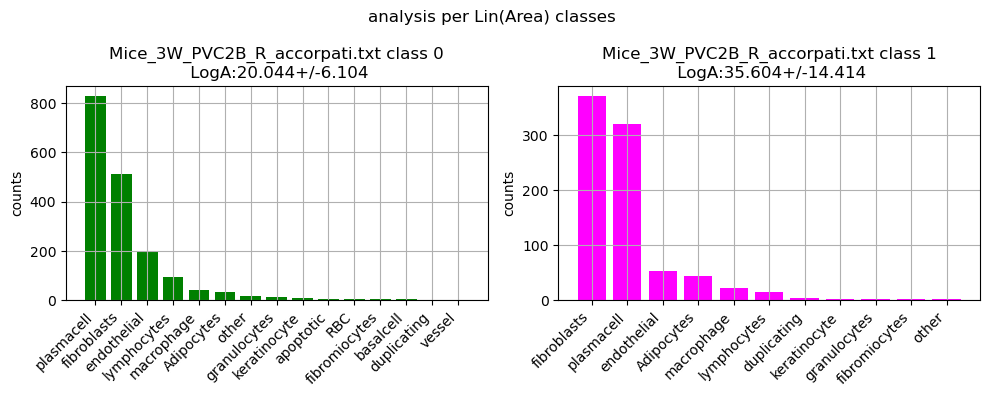

In [14]:
############ THIS IS THE PART OF THE CODE WHERE I GET THE MAJOR FEATURES
# ##########  ON THE AREA of the nuclei AND ASSIGN IT TO THE MOST 
#### INFLUENCING/ED CELLS


######################### analaysis per GRANUlariTY classes 
F1,A1 = plt.subplots(1,2,figsize=(10,4))
F1.suptitle('analysis per Lin(Area) classes ')

#### create the sorted subsets 

#probAreas,

sorted_df_LinA1 = GetSubsetClass(Urdf,indices_class_LinArea1)

iframe = 1
A1[iframe].bar(sorted_df_LinA1['types'] ,sorted_df_LinA1['counts'],color='magenta')
A1[iframe].set_xticklabels(sorted_df_LinA1['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class ' + str(iframe))
A1[iframe].grid()

#### create the sorted subsets 
sorted_df_LinA0 = GetSubsetClass(Urdf,indices_class_LinArea0)

iframe = 0
A1[iframe].bar(sorted_df_LinA0['types'] ,sorted_df_LinA0['counts'],color='green')
A1[iframe].set_xticklabels(sorted_df_LinA0['types'],size=10,rotation = 45,ha='right')
A1[iframe].set_ylabel('counts')
#A1[iframe].set_title(Urname+' class '+str(iframe))
A1[iframe].grid()


### evaluation of the average eccentricity per type of cells and average probability
## colors_GM, proba, indices_class_0,indices_class_1,numeric_labels =  GaussianMixModel(data)
### we do it over class0
### let's say that we look at the first 3 most populated classes
### sorted_Df0 anjd sorted_df1 are the dataframes with the class0 and class 1 ordered

print ('---------------------------------------------\n ')
LinA_ave0 = [np.round(x1a,3),np.round(x1s,3)]
A1[0].set_title(Urname+' class '+str(0)+'\n LogA:'+str(LinA_ave0[0])+'+/-'+str(LinA_ave0[1]))

print('--------- feature defijntion step 1: sorted df, class0, LogARea:', np.round(x1a,3))

#### these are dataframes with the probabilities of belongin to a class.
df_res0_LinA = Create_dfRes(sorted_df_LinA0, Urdf, indices_class_LinArea0,probLinAreas)

LinA_ave1 = [np.round(x2a,3),np.round(x2s,3)]
A1[1].set_title(Urname+' class '+str(1)+'\n LogA:'+str(LinA_ave1[0])+'+/-'+str(LinA_ave1[1]))
print ('------------------  feature defintion step 1: sorted df, class1, LogArea:', np.round(x2a,3))

df_res1_LinA = Create_dfRes(sorted_df_LinA1, Urdf, indices_class_LinArea1,probLinAreas)
print (" ---- THE FINAL STEP : checking for the largest in-class occurence ----")
#### search each of the uniques entries for the largest belonging probability and then select the corresponding class0 probability

df_FEATURES_Area = Create_FEATURES(dfCellsTypes,df_res0_LinA,df_res1_LinA)

df_Classification_LinArea =   pd.DataFrame(columns=["Type","Class", "ProbLinArea_Avg", "ProbLinArea_Std"])  

Thr_App   = 45
Thr_Count = 30
for k in range(len(df_FEATURES_Area)):
    U = df_FEATURES_Area.iloc[k]["Type"]
    ##### numnber of cells in the 2 classes 
    filtered_df_res = df_res0_LinA[df_res0_LinA['Type'] == U]["ProbApp (%)"]
    if not filtered_df_res.empty:
        prob_App_class0 = filtered_df_res.values[0]

    filtered_df_res = df_res1_LinA[df_res1_LinA['Type'] == U]["ProbApp (%)"]
    if not filtered_df_res.empty:
        prob_App_class1 = filtered_df_res.values[0]

    C0 = dfCellsTypes[dfCellsTypes['types'] == df_FEATURES_Area.iloc[k]["Type"]]['counts'].values[0]
    #print(U,C0,df_FEATURES.iloc[k]["ProbAppEcc (%)"],df_FEATURES.iloc[k]["Class"] )
    if df_FEATURES_Area.iloc[k]["ProbAppEcc (%)"] > Thr_App and C0 >Thr_Count:
        print (k,C0,df_FEATURES_Area.iloc[k]["Type"],df_FEATURES_Area.iloc[k]["Class"],df_FEATURES_Area.iloc[k]["ProbAppEcc (%)"],
               df_FEATURES_Area.iloc[k]["ProbEcc_Avg"],np.round(prob_App_class0,1),np.round(prob_App_class1,1))
        df_Classification_LinArea.loc[len(df_Classification_LinArea)] = [
                U,
                df_FEATURES_Area.iloc[k]["Class"],
                df_FEATURES_Area.iloc[k]["ProbEcc_Avg"],
                df_FEATURES_Area.iloc[k]["ProbEcc_Std"]/np.sqrt(df_FEATURES_Area.iloc[k]["Ncells"])
                 
            ]

print (df_Classification_LinArea)

plt.tight_layout()

In [15]:
#print (df_Classification_LogArea.iloc[0])
#print (df_Classification_F)
#print (df_Classification_G)
#print (dfCellsTypes)

df_U_Classification =   pd.DataFrame(
    columns=["Type",
            "ClassE",
            "ProbEcc_Avg",
            "ProbEcc_Std",
            "ClassFract",
            "ProbFrac_Avg",
            "ProbFrac_Std",
            "ClassGranul",
            "ProbGranul_Avg",
            "ProbGranul_Std",
            "ClassLogArea",
            "ProbLogArea_Avg",
            "ProbLogArea_Std",
            "ClassLinArea",
            "ProbLinArea_Avg",
            "ProbLinArea_Std"]
            )  

for  U  in dfCellsTypes["types"]:

    U_slice_E = df_Classification_E[ df_Classification_E["Type"]==U ]
    U_slice_F = df_Classification_F[ df_Classification_F["Type"]==U ]
    U_slice_G = df_Classification_G[ df_Classification_G["Type"]==U ]
    U_slice_L = df_Classification_LogArea[ df_Classification_LogArea["Type"]==U ]
    U_slice_A = df_Classification_LinArea[ df_Classification_LinArea["Type"]==U ]
    empty_count = sum([
        U_slice_E.empty,
        U_slice_F.empty,
        U_slice_G.empty,
        U_slice_L.empty
    ])
    
    if (not U_slice_E.empty) and (not U_slice_F.empty) and (not U_slice_G.empty) and (not U_slice_L.empty): 
        #print (df_Classification_E[ df_Classification_E["Type"]==U ])
        #print (df_Classification_F[ df_Classification_F["Type"]==U ])
        #print (df_Classification_G[ df_Classification_G["Type"]==U ])
        #print (df_Classification_LogArea[ df_Classification_LogArea["Type"]==U ])
        df_U_Classification.loc[len(df_U_Classification)]= [
            U_slice_E["Type"],
            U_slice_E["Class"],
            U_slice_E["ProbEcc_Avg"],
            U_slice_E["ProbEcc_Std"],
            U_slice_F["Class"],
            U_slice_F["ProbFrac_Avg"],
            U_slice_F["ProbFrac_Std"],
            U_slice_G["Class"],
            U_slice_G["ProbGranul_Avg"],
            U_slice_G["ProbGranul_Std"],
            U_slice_L["Class"],
            U_slice_L["ProbLogArea_Avg"],
            U_slice_L["ProbLogArea_Std"],
            U_slice_A["Class"],
            U_slice_A["ProbLinArea_Avg"],
            U_slice_A["ProbLinArea_Std"]
            ]

    else:
        print (' No results for ',U)
        break


print ("  Celltype   Ecc   Fract  Granul    LogA   LinA")
for k in range(len(df_U_Classification)):
    print ("{:<12} {:<7} {:<7} {:<7} {:<7} {:<7}".format(
        df_U_Classification.iloc[k]["Type"].values[0],
#        df_U_Classification.iloc[k]["ClassE"].values[0], round(df_U_Classification.iloc[k]["ProbEcc_Avg"].values[0],3),
        df_U_Classification.iloc[k]["ClassE"].values[0],
#        df_U_Classification.iloc[k]["ClassFract"].values[0], round(df_U_Classification.iloc[k]["ProbFrac_Avg"].values[0],3),
        df_U_Classification.iloc[k]["ClassFract"].values[0],
        df_U_Classification.iloc[k]["ClassGranul"].values[0],
        df_U_Classification.iloc[k]["ClassLogArea"].values[0],
        df_U_Classification.iloc[k]["ClassLinArea"].values[0]))


 No results for  granulocytes
  Celltype   Ecc   Fract  Granul    LogA   LinA
fibroblasts  1       1       1       1       0      
plasmacell   0       0       1       1       0      
endothelial  1       1       1       1       0      
Adipocytes   1       1       1       1       1      
lymphocytes  0       0       0       0       0      
macrophage   0       1       0       1       0      


In [71]:

df_U_Classification =   pd.DataFrame(
    columns=["Type",
            "ClassE",
            "ProbEcc_Avg",
            "ProbEcc_Std",
            "ClassFract",
            "ProbFrac_Avg",
            "ProbFrac_Std",
            "ClassGranul",
            "ProbGranul_Avg",
            "ProbGranul_Std",
            "ClassLogArea",
            "ProbLogArea_Avg",
            "ProbLogArea_Std",
            "ClassLinArea",
            "ProbLinArea_Avg",
            "ProbLinArea_Std"]
            )  

for  U  in dfCellsTypes["types"]:

    U_slice_E = df_Classification_E[ df_Classification_E["Type"]==U ]
    U_slice_F = df_Classification_F[ df_Classification_F["Type"]==U ]
    U_slice_G = df_Classification_G[ df_Classification_G["Type"]==U ]
    U_slice_L = df_Classification_LogArea[ df_Classification_LogArea["Type"]==U ]
    U_slice_l = df_Classification_LinArea[ df_Classification_LinArea["Type"]==U ]
    
    empty_count = sum([
        U_slice_E.empty,
        U_slice_F.empty,
        U_slice_G.empty,
        U_slice_L.empty,
        U_slice_l.empty
    ])
    #print (U,'e:',empty_count)
    
    if empty_count <= 1:
        df_U_Classification.loc[len(df_U_Classification)] = [
            U_slice_E["Type"].values[0] if not U_slice_E.empty else -1,
            U_slice_E["Class"].values[0] if not U_slice_E.empty else -1,
            U_slice_E["ProbEcc_Avg"].values[0] if not U_slice_E.empty else -1,
            U_slice_E["ProbEcc_Std"].values[0] if not U_slice_E.empty else -1,

            U_slice_F["Class"].values[0] if not U_slice_F.empty else -1,
            U_slice_F["ProbFrac_Avg"].values[0] if not U_slice_F.empty else -1,
            U_slice_F["ProbFrac_Std"].values[0] if not U_slice_F.empty else -1,

            U_slice_G["Class"].values[0] if not U_slice_G.empty else -1,
            U_slice_G["ProbGranul_Avg"].values[0] if not U_slice_G.empty else -1,
            U_slice_G["ProbGranul_Std"].values[0] if not U_slice_G.empty else -1,

            U_slice_L["Class"].values[0] if not U_slice_L.empty else -1,
            U_slice_L["ProbLogArea_Avg"].values[0] if not U_slice_L.empty else -1,
            U_slice_L["ProbLogArea_Std"].values[0] if not U_slice_L.empty else -1,

            U_slice_l["Class"].values[0] if not U_slice_L.empty else -1,
            U_slice_l["ProbLinArea_Avg"].values[0] if not U_slice_L.empty else -1,
            U_slice_l["ProbLinArea_Std"].values[0] if not U_slice_L.empty else -1]

    else:
        print (' No results for ',U,empty_count)
    
LLEN =  (len(df_U_Classification))

for k in range(LLEN):

#    print ("{:<12} {:<7} {:<7} {:<7} {:<7} {:<7} {:<7}  {:<7}".format(
    print ("{:<12} {:<7} {:<7} {:<7} {:<7} {:<7}".format(
        df_U_Classification.iloc[k]["Type"],
        df_U_Classification.iloc[k]["ClassE"], #, round(df_U_Classification.iloc[k]["ProbEcc_Avg"],3),
        df_U_Classification.iloc[k]["ClassFract"], # round(df_U_Classification.iloc[k]["ProbFrac_Avg"],3),
        df_U_Classification.iloc[k]["ClassGranul"],
        df_U_Classification.iloc[k]["ClassLogArea"],
        df_U_Classification.iloc[k]["ClassLinArea"]))




 No results for  granulocytes 5
 No results for  other 5
 No results for  keratinocyte 5
 No results for  duplicating 5
 No results for  RBC 5
 No results for  fibromiocytes 5
 No results for  basalcell 5
 No results for  vessel 5
 No results for  apoptotic 5
fibroblasts  1       1       1       1       0      
plasmacell   0       0       1       1       0      
endothelial  1       1       1       1       0      
Adipocytes   1       1       1       1       1      
lymphocytes  0       0       0       0       0      
macrophage   0       1       0       1       0      


In [73]:
print('               Class0        Class1')
print('Eccentricity:',np.round(NucEcc[indices_class_0].mean(),2) ,'         ',  np.round(NucEcc[indices_class_1].mean(),2))
print('Granularity :',np.round(NucGranul[indices_class_0].mean(),2) ,'         ', np.round(NucGranul[indices_class_1].mean(),2))
print('Fractality  :',np.round(singleNucleus_fractal[indices_class_0].mean(),2) ,'         ', np.round(singleNucleus_fractal[indices_class_1].mean(),2))
print('LogArea     :',np.round(LogArea_class0,1) ,'         ', np.round(LogArea_class1,1))
print('LinArea     :',np.round(LinArea_class0,1) ,'         ', np.round(LinArea_class1,1))


               Class0        Class1
Eccentricity: 0.7           0.91
Granularity : 0.31           0.34
Fractality  : 1.38           1.33
LogArea     : 2.8           3.3
LinArea     : 20.0           35.6


stat analysis on the Areas' ratio 
average-ratioAA: 1.58 +/- 0.007
average-ratioAB: 1.53 +/- 0.008
T-statistic: 4.562548759144044
P-value: 5.544281120083653e-06
Significant difference between groups (p < 0.05)
A00,ratioAmax =  1.56 ; nucl. perim. max =  22.03
-------- File Mice_3W_PVC2A_newColorDEconv_LabelAreaRatioA_Ecc.csv has been created !!!!
A01,ratioAmax =  1.54 ; nucl. ecc. max =  0.98
<RatioclassA, Nucl Ecc. class 0: 0.97 +/- 0.01
<RatioclassA, Nucl Ecc. class 1: 0.92 +/- 0.02
A10,ratioBmax =  1.52 ; nucl. perim. max =  16.57
-------- File Mice_3W_PVC2A_newColorDEconv_LabelAreaRatioB_Ecc.csv has been created !!!!
-------- File Mice_3W_PVC2A_newColorDEconv_LabelAreaRatioAB_Ecc.csv has been created !!!!
A11,ratioBmax =  1.46 ; nucl. ecc. max =  0.84
<RatioclassB, Nucl Ecc. class 0: 0.7  +/-  0.15
<RatioclassB, Nucl Ecc. class 1: 0.86  +/- 0.08
average-whole EccNuclAA: 0.95 +/- 0.001
average-whole EccNuclAB: 0.76 +/- 0.006
T-statistic: 32.811244763628146
P-value: 2.204351659552097

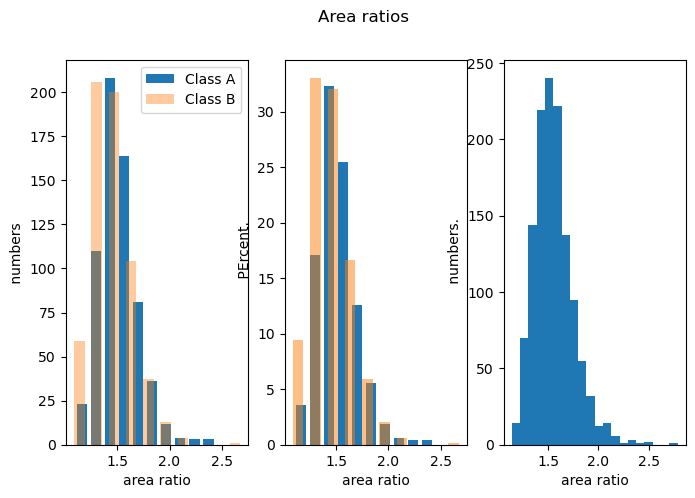

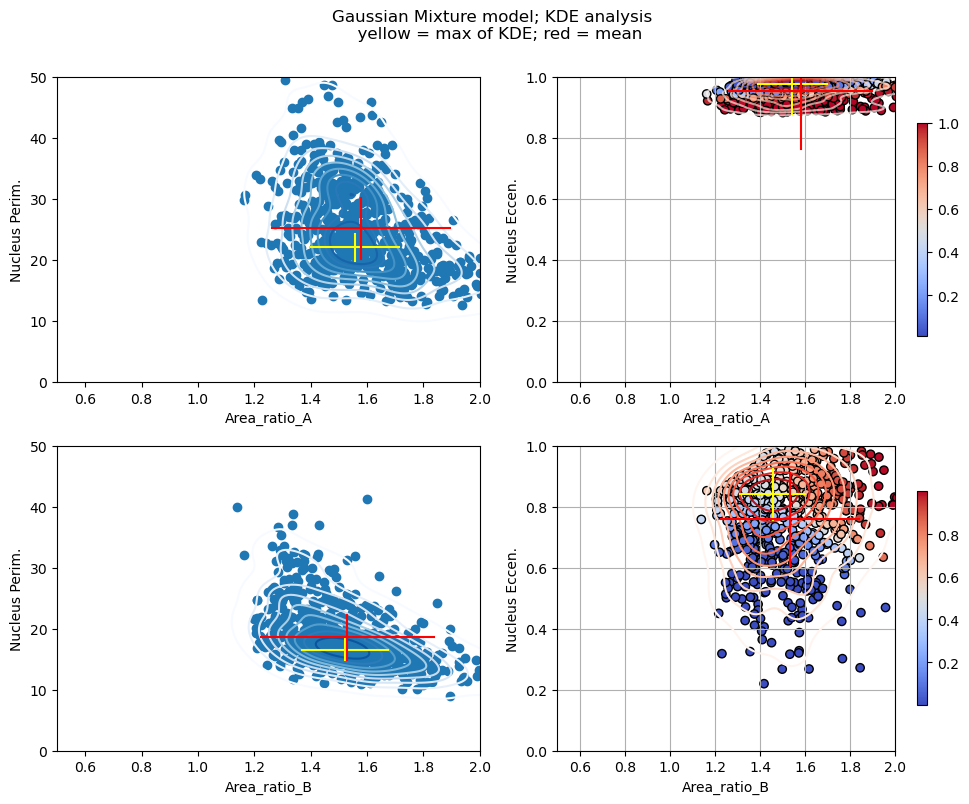

In [25]:
''' 
Analysis within the two areas ratio classes of the eccentricity and perimeter

'''
import scipy.stats as stats
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

def getMax(data,kdeplot):
# Compute KDE using scipy over a grid
    x_values    = np.linspace(data['x'].min(), data['x'].max(), 100)
    y_values    = np.linspace(data['y'].min(), data['y'].max(), 100)
    X, Y        = np.meshgrid(x_values, y_values)
    positions   = np.vstack([X.ravel(), Y.ravel()])
    kde = gaussian_kde(data[['x', 'y']].T)
    Z = kde(positions).reshape(X.shape)
##################################################################################
# Find max density position
    max_index = np.unravel_index(np.argmax(Z, axis=None), Z.shape)
    max_x, max_y = X[max_index], Y[max_index]

    return (max_x,max_y)
##################################################################################


def StatisticalAnalysis(data1,Lab1,data2,Lab2):
    mean_AA = np.mean(data1)
    std_AA = np.std(data1)

    mean_AB = np.mean(data2)
    std_AB = np.std(data2)
    
    print ('average-'+Lab1+':',round(mean_AA,2),'+/-',round(std_AA/np.sqrt(len(ratioAA)),3))
    print ('average-'+Lab2+':',round(mean_AB,2),'+/-',round(std_AB/np.sqrt(len(ratioAB)),3) )


# Perform independent t-test (assuming equal variance)
    t_stat, p_value = stats.ttest_ind(data1, data2)

    print(f"T-statistic: {t_stat}")
    print(f"P-value: {p_value}")

# Interpretation
    if p_value < 0.05:
        print("Significant difference between groups (p < 0.05)")
    else:
        print("No significant difference (p >= 0.05)")

    return mean_AA,std_AA/np.sqrt(len(ratioAA)),mean_AB,std_AB/np.sqrt(len(ratioAB))


####  WE WANT TO ANALYZE THE RATIO OF THE CELL/NUCLEUS AREAS
###class A == monocytes ??


ratioAA = np.log(dfAreas.iloc[indices_class_0,1]) / np.log(dfAreas.iloc[indices_class_0,0])
ratioAB = np.log(dfAreas.iloc[indices_class_1,1]) / np.log(dfAreas.iloc[indices_class_1,0])

indA    = indices_class_0.astype(int)  ### these are the classes of the area ratios
indB    = indices_class_1.astype(int)
####################   first plot of the distributiuons of the Areas
F,A = plt.subplots(1,3,figsize=(8,5))

histA, binsA = np.histogram(ratioAA, bins=10)
histB, binsB = np.histogram(ratioAB, bins=10)

data1       = ratioAA
Lab1        = 'ratioAA'
data2       = ratioAB
Lab2        = 'ratioAB'

print('stat analysis on the Areas\' ratio ')
mratio1,s1,mratio2,s2 = StatisticalAnalysis(data1,Lab1,data2,Lab2)

A[0].bar(binsA[:-1],histA,label='Class A',width=0.1)
A[0].bar(binsB[:-1],histB,alpha=0.4,label='Class B',width=0.1)
A[0].set_xlabel('area ratio')
A[0].set_ylabel(' numbers ')
A[0].legend()

A[1].bar(binsA[:-1],100*histA/np.sum(histA),width=0.1)
A[1].bar(binsB[:-1],100*histB/np.sum(histB),alpha=0.5,width=0.1)
A[1].set_xlabel('area ratio')
A[1].set_ylabel(' PErcent.')
A[0].legend()

A[2].hist(np.hstack((ratioAA,ratioAB)),bins=20)
A[2].set_xlabel('area ratio')
A[2].set_ylabel(' numbers.')
F.suptitle('Area ratios ')

#################  curve lines  plot 
LabelA  = 'Class A'
LabelB  = 'Class B'

F2,A2 = plt.subplots(2,2,figsize=(10,8))
for ax in A2.flatten():
    ax.set_xlim(0.5,2)


########### 00
ic      = 0   #### Nucleus:Perimeter	Nucleus:Eccentricity	Cell:perimeter	Cell:Eccentricity
data3   = df.values[indA[:],ic] ##nuclear perim A
A2[0,0].scatter(ratioAA[:],df.values[indA[:],ic])

pippo0  = np.asarray(ratioAA[:], dtype=np.float64)
pippo1  = np.asarray(df.values[indA[:],ic], dtype=np.float64)

#data = pd.DataFrame({'x': ratioAA[:], 'y': df.values[indA[:],ic]})
data = pd.DataFrame({'x': pippo0, 'y': pippo1})

A2[0,0].set_xlabel('Area_ratio_A')
A2[0,0].set_ylabel('Nucleus Perim.')
A2[0,0].set_ylim(0,50)

# Use keyword arguments for x and y
kdeplot = sns.kdeplot(data=data, x='x', y='y', ax=A2[0,0], cmap="Blues", fill=False)
max_x,max_y = getMax(data,kdeplot)
print ('A00,ratioAmax = ',np.round(max_x,2),'; nucl. perim. max = ',np.round(max_y,2))

A2[0,0].plot([max_x*0.9,max_x*1.1 ],[max_y,max_y],color='yellow')
A2[0,0].plot([max_x,max_x],[max_y*0.9,max_y*1.1 ],color='yellow')




####################### 01
ic      = 1
data1   = df.values[indA[:],ic] ##nuclear eccent.
x       = ratioAA[:].astype(np.float64)
y       = data1.astype(np.float64)

########################   USE KDE  FOR CLUSTERING -- NEW
dataxy                = np.column_stack((x,y))  # Shape (200, 2)
colors_GM, probArea_Ecc,indices_class_AE0,indices_class_AE1,numeric_labels =  GaussianMixModel(dataxy)
I2_01 = A2[0,1].scatter(ratioAA[:],df.values[indA[:],ic],c=probArea_Ecc[:, 1], cmap='coolwarm', edgecolors="k")
plt.colorbar(I2_01,ax=A2[0,1],shrink=0.7)
data = pd.DataFrame({'x': ratioAA[:], 'y': df.values[indA[:],ic]})
data['x'] = pd.to_numeric(data['x'], errors='coerce')
data['y'] = pd.to_numeric(data['y'], errors='coerce')
data = data.dropna(subset=['x', 'y'])

# Save to a CSV file -----------------------------
Fout        = prenome + '_LabelAreaRatioA_Ecc.csv'
rows = []
for R in indices_class_AE0:
    row = {
        'R': R,
        'ObjectID':     df.values[indA[R], 5],
        'IndexInA':     indA[R],
        'RatioAA' :     np.log(dfAreas.iloc[indA[R],1]) / np.log(dfAreas.iloc[indA[R],0]),
        'ProbArea_Ecc': probArea_Ecc[R][0],
        'Eccentricity': df.values[indA[R], ic],
        'NuclPerim': df.values[indA[R], 0],
        'labelCell':    'A_Ecc_0'
    }
    rows.append(row)
for R in indices_class_AE1:
    row = {
        'R': R,
        'ObjectID':     df.values[indA[R], 5],
        'IndexInA':     indA[R],
        'RatioAA' :     np.log(dfAreas.iloc[indA[R],1]) / np.log(dfAreas.iloc[indA[R],0]),
        'ProbArea_Ecc': probArea_Ecc[R][0],
        'Eccentricity': df.values[indA[R], ic],
        'NuclPerim': df.values[indA[R], 0],
        'labelCell':    'A_Ecc_1'
    }
    rows.append(row)

outputA_df = pd.DataFrame(rows)

outputA_df.to_csv(path+Fout, index=False)
print("-------- File " + Fout + " has been created !!!!")
# ---------------------------------------------------

# Use keyword arguments for x and y
kdeplot = sns.kdeplot(data=data, x='x', y='y', ax=A2[0,1], cmap="Reds", fill=False,levels = 10,alpha = 0.7)
max_x,max_y = getMax(data,kdeplot)
print ('A01,ratioAmax = ',np.round(max_x,2),'; nucl. ecc. max = ',np.round(max_y,2))

print ('<RatioclassA, Nucl Ecc. class 0:', np.round(data1[indices_class_AE0].mean(),2) ,'+/-', np.round(data1[indices_class_AE0].std(),2))
print ('<RatioclassA, Nucl Ecc. class 1:', np.round(data1[indices_class_AE1].mean(),2) , '+/-', np.round(data1[indices_class_AE1].std(),2))

A2[0,1].plot([max_x*0.9,max_x*1.1 ],[max_y,max_y],color='yellow')
A2[0,1].plot([max_x,max_x],[max_y*0.9,max_y*1.1 ],color='yellow')

A2[0,1].set_xlabel('Area_ratio_A')
A2[0,1].set_ylabel('Nucleus Eccen.')
A2[0,1].set_ylim(0,1)
A2[0,1].grid(True)







############ 10
ic      = 0
data4   = df.values[indB[:],ic] ##nuclear Perim. B
A2[1,0].scatter(ratioAB[:],df.values[indB[:],ic])
data = pd.DataFrame({'x': ratioAB[:], 'y': df.values[indB[:],ic]})

data['x'] = pd.to_numeric(data['x'], errors='coerce')
data['y'] = pd.to_numeric(data['y'], errors='coerce')
data = data.dropna(subset=['x', 'y'])

# Use keyword arguments for x and y
kdeplot = sns.kdeplot(data=data, x='x', y='y', ax=A2[1,0], cmap="Blues", fill=False)
max_x,max_y = getMax(data,kdeplot)
print ('A10,ratioBmax = ',np.round(max_x,2),'; nucl. perim. max = ',np.round(max_y,2))

A2[1,0].plot([max_x*0.9,max_x*1.1 ],[max_y,max_y],color='yellow')
A2[1,0].plot([max_x,max_x],[max_y*0.9,max_y*1.1 ],color='yellow')

A2[1,0].set_xlabel('Area_ratio_B')
A2[1,0].set_ylabel('Nucleus Perim.')
A2[1,0].set_ylim(0,50)



########  11
ic      = 1
data2   = df.values[indB[:],ic] ##nuclear eccent.
#A2[1,1].scatter(ratioAB[:],df.values[indB[:],ic])

########################   USE KDE  FOR CLUSTERING -- NEW
dataxy                = np.column_stack((ratioAB[:],df.values[indB[:],ic]))  
colors_GM, probArea_EccB,indices_class_BE0,indices_class_BE1,numeric_labels =  GaussianMixModel(dataxy)
I2_11 = A2[1,1].scatter(ratioAB[:],df.values[indB[:],ic],c=probArea_EccB[:, 1], cmap='coolwarm', edgecolors="k")
plt.colorbar(I2_11,ax=A2[1,1],shrink=0.7)


data = pd.DataFrame({'x': ratioAB[:], 'y': df.values[indB[:],ic]})
data['x'] = pd.to_numeric(data['x'], errors='coerce')
data['y'] = pd.to_numeric(data['y'], errors='coerce')
data = data.dropna(subset=['x', 'y'])

# Save to a CSV file -----------------------------
Fout        = prenome + '_LabelAreaRatioB_Ecc.csv'
rows = []
for R in indices_class_BE0:
    row = {
        'R': R,
        'ObjectID': df.values[indB[R], 5],
        'IndexInB': indB[R],
        'RatioAB' : np.log(dfAreas.iloc[indB[R],1]) / np.log(dfAreas.iloc[indB[R],0]),
        'ProbArea_Ecc': probArea_EccB[R][0],
        'Eccentricity': df.values[indB[R], ic],
        'NuclPerim': df.values[indB[R], 0],
            'labelCell':    'B_Ecc_0'
    }
    rows.append(row)
for R in indices_class_BE1:
    row = {
        'R': R,
        'ObjectID': df.values[indB[R], 5],
        'IndexInB': indB[R],
        'RatioAB' : np.log(dfAreas.iloc[indB[R],1]) / np.log(dfAreas.iloc[indB[R],0]),
        'ProbArea_Ecc': probArea_EccB[R][0],
        'Eccentricity': df.values[indB[R], ic],
        'NuclPerim': df.values[indB[R], 0],
        'labelCell':    'B_Ecc_1'
    }
    rows.append(row)

outputB_df = pd.DataFrame(rows)

outputB_df.to_csv(path+Fout, index=False)
print("-------- File " + Fout + " has been created !!!!")
# ---------------------------------------------------
########################   now merge the two datasets and output a single sorted file according to indA and inB, column =2
merged_df = pd.concat([outputA_df, outputB_df], ignore_index=True)

Fout        = prenome + '_LabelAreaRatioAB_Ecc.csv'

# Sort by the third column (index 2 or column name 'C')
sorted_df = merged_df.sort_values(by=merged_df.columns[2])
sorted_df.to_csv(path+Fout, index=False)

print("-------- File " + Fout + " has been created !!!!")


# Use keyword arguments for x and y
kdeplot=sns.kdeplot(data=data, x='x', y='y', ax=A2[1,1], cmap="Reds", fill=False)

max_x,max_y = getMax(data,kdeplot)
print ('A11,ratioBmax = ',np.round(max_x,2),'; nucl. ecc. max = ',np.round(max_y,2))
print ('<RatioclassB, Nucl Ecc. class 0:', np.round(data2[indices_class_BE0].mean(),2),' +/- ', np.round(data2[indices_class_BE0].std(),2))
print ('<RatioclassB, Nucl Ecc. class 1:', np.round(data2[indices_class_BE1].mean(),2),' +/-', np.round(data2[indices_class_BE1].std(),2))


A2[1,1].plot([max_x*0.9,max_x*1.1 ],[max_y,max_y],color='yellow')
A2[1,1].plot([max_x,max_x],[max_y*0.9,max_y*1.1 ],color='yellow')

A2[1,1].set_xlabel('Area_ratio_B')
A2[1,1].set_ylabel('Nucleus Eccen.')
A2[1,1].set_ylim(0,1)
A2[1,1].grid(True)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.3)


Lab1        = 'whole EccNuclAA'   # data1
Lab2        = 'whole EccNuclAB'    # data 2

mecc1,s1,mecc2,s2 = StatisticalAnalysis(data1.astype(np.float64),Lab1,data2.astype(np.float64),Lab2)
Lab1        = 'whole PerimNuclAA'   #data 3
Lab2        = 'Whole PerimNuclAB'   # data 4
mper1,s1,mper2,s2 = StatisticalAnalysis(data3.astype(np.float64),Lab1,data4.astype(np.float64),Lab2)


A2[0,0].plot([mratio1*0.8,mratio1*1.2], [mper1,mper1],  color='red', label="Target Point")
A2[0,0].plot([mratio1,mratio1], [mper1*0.8,mper1*1.2],  color='red', label="Target Point")
A2[0,1].plot([mratio1*0.8,mratio1*1.2], [mecc1,mecc1],  color='red', label="Target Point")
A2[0,1].plot([mratio1,mratio1], [mecc1*0.8,mecc1*1.2],  color='red', label="Target Point")

A2[1,0].plot([mratio2*0.8,mratio2*1.2], [mper2,mper2],  color='red', label="Target Point")
A2[1,0].plot([mratio2,mratio2], [mper2*0.8,mper2*1.2],  color='red', label="Target Point")
A2[1,1].plot([mratio2*0.8,mratio2*1.2], [mecc2,mecc2],  color='red', label="Target Point")
A2[1,1].plot([mratio2,mratio2], [mecc2*0.8,mecc2*1.2],  color='red', label="Target Point")
    
F2.suptitle('Gaussian Mixture model; KDE analysis \n  yellow = max of KDE; red = mean',y=1)
plt.tight_layout()



In [209]:
print (outputA_df.values[0])
print (outputB_df.values[0])
print(outputA_df.columns.tolist())
print(outputB_df.columns.tolist())
outputA_df.columns = outputA_df.columns.str.strip()
outputB_df.columns = outputB_df.columns.str.strip()


[1 '44c63307-022d-4d2b-a0f1-aa7bfb4e4f11' 1 1.2959543583814617
 0.9896391383020458 0.7778 'A_Ecc_0']
[0 'f5f86a60-9bab-4dfc-978b-c18b03f4aaf6' 4 1.712953323877887
 0.7326276799762771 0.5375 'B_Ecc_0']
['R', 'ObjectID', 'IndexInA', 'RatioAA', 'ProbArea_Ecc', 'Eccentricity', 'labelCell']
['R', 'ObjectID', 'IndexInB', 'RatioAB', 'ProbArea_Ecc', 'Eccentricity', 'labelCell']


In [197]:

print (indA.shape, indB.shape, NumTotalData)
print (indices_class_AE0.shape,indices_class_AE1.shape,indices_class_BE0.shape, indices_class_BE1.shape)

(136,) (156,) 292
(100,) (36,) (100,) (56,)


In [36]:
''' 
write out the flags for the classes
        '''

print (proba.shape, probAreas.shape,probArea_Ecc.shape,probArea_EccB.shape,indA.shape,indB.shape)
NumA = indA.size
NumB = indB.size
Lout = []
for kk in range(proba.shape[0]):
#    print(kk , indA[kk] , np.round(probAreas[indA[kk]],2),np.round(probArea_Ecc[indA[kk]],2))
    if kk in indA:
        posA = np.where(indA == kk)[0][0]
        label = 'A'
        Prob_Eccentricity = probArea_Ecc[posA]
        Prob_ratio        = probAreas[kk]
        Lout.append([kk,posA,label,Prob_ratio[0],Prob_ratio[1],Prob_Eccentricity[0],Prob_Eccentricity[1]])
#        print ('indA:',kk,posA,label,Prob_ratio,Prob_Eccentricity)
    elif kk in indB:
        posB = np.where(indB == kk)[0][0]  
        label = 'B'
        Prob_Eccentricity = probArea_EccB[posB]
        prob_ratio        = probAreas[kk]
        Lout.append([kk,posB,label,Prob_ratio[0],Prob_ratio[1],Prob_Eccentricity[0],Prob_Eccentricity[1]])
        #print ('indB:',kk,posB,label,Prob_ratio,Prob_Eccentricity)
    else:
        print ('error')

Aout = np.array(Lout)
print (Aout.shape)
column_labels = ["kk", "posAB", "class_A_Ratio", "probareaA", "probareaB", "probEcc1", "probEcc2"]




df_output = pd.DataFrame(Aout,columns = column_labels)
df_output.to_csv(path+'flags.csv',index=False)

(2621, 2) (2621, 2) (1236, 2) (1385, 2) (1236,) (1385,)
(2621, 7)


open file: Document1_12-46-02_PMT - PMT [PMT1 - xyz-Table[2] - xyz-Table[0]] PMT - PMT [PMT1 - xyz-Table[1] - xyz-Table[1]] _C0.
(5, 137, 507, 507)
G:\Shared drives\FET-IN2SIGHT\Work\WP4_invivoImaging\2025-17-03_IN2SIGHT_DATA_UNIMIB_THGatGeneve\sample2\Im1Mosaic\im1 mosaic\data\Document1_12-46-02_PMT - PMT [PMT1 - xyz-Table[2] - xyz-Table[0]] PMT - PMT [PMT1 - xyz-Table[1] - xyz-Table[1]] _C0.Gc3_12_4.tif
Estimated Shift: [0. 0.]
Check Shift: [0. 0.]
Estimated Shift: [ 1. -1.]
Check Shift: [0. 0.]
Estimated Shift: [ 1. -2.]
Check Shift: [0. 0.]
Estimated Shift: [ 1. -2.]
Check Shift: [0. 0.]
Contains NaN: False
Contains Inf: False
(507, 507)
[180349  49622  13564   5903   2992   1753   1088    668    432    244
    152    118     70     47     21     17      6      1      1      1]


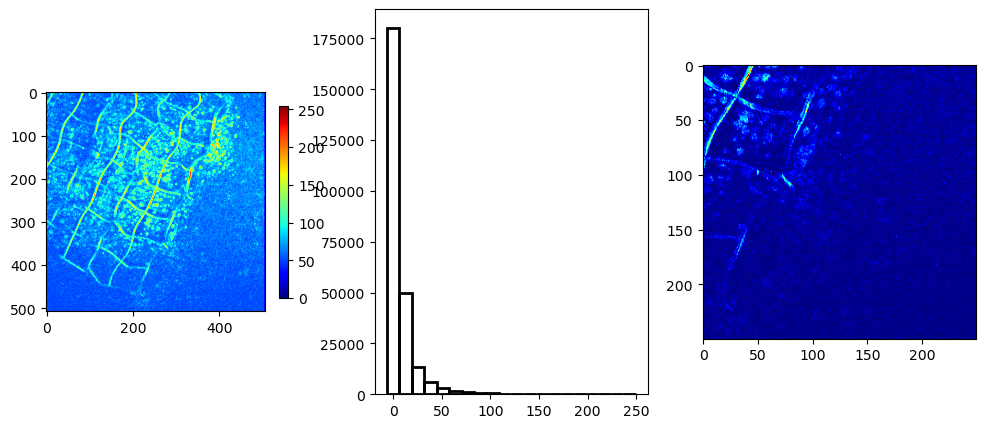

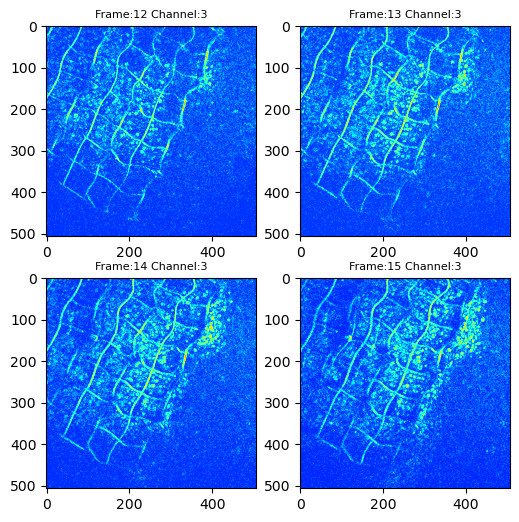

In [ ]:
###tis is the copy of the first cell to perform averaging over stacks 
import numpy as np
import tifffile as tiff
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

FLAG_verbose = 'n'

if FLAG_verbose == 'y':
    gamma               = float(input('gamma factor?'))
    frame_index         = int(input('initial frame index?'))
    N0                  = int(input('number of frames to average [N0*N0] ?'))
    Thr_backg_rej       = float(input('threshold to subtract [fractiuon of the minimum : 0-1]'))   

else:
    frame_index         = 12 # Choose the initial frame
    gamma               = 0.4
    Thr_backg_rej       =   1
    N0                  = 2

def gamma_correction(image, gamma):
    # Build lookup table
    lookup_table = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype("uint8")

    # Apply correction
    corrected_img = cv2.LUT(image, lookup_table)
    return corrected_img


def gamma_correction(image_array, gamma):
    """
    Apply gamma correction to a NumPy image array.
    """
    # Normalize image (convert to range 0-1)
    normalized = image_array / 255.0

    # Apply gamma correction formula
    corrected = np.power(normalized, gamma)

    # Convert back to 8-bit format (0-255)
    return (corrected * 255).astype(np.uint8)


def normImage(im):
    return 256*(im - im.min())/(im.max()-im.min())

# Load the TIFF file
path = 'G:\\Shared drives\\FET-IN2SIGHT\\Work\\WP4_invivoImaging\\2025-17-03_IN2SIGHT_DATA_UNIMIB_THGatGeneve\\sample2\\Im1Mosaic\im1 mosaic\\data\\'

FF   = 'Document1_12-46-02_PMT - PMT [PMT1 - xyz-Table[2] - xyz-Table[0]] PMT - PMT [PMT1 - xyz-Table[1] - xyz-Table[1]] _C0.'
fname       = path+FF+'ome.tif'
print ('open file:', FF)
image = tiff.imread(fname)

fout = FF.split('PMT - PMT')[2]+'f'+str(frame_index)+'-nf'+str(Num_frames)+'-ch'+str(channel_index)+'.dat'

# Check the shape of the image (dimensions)
print(image.shape)  # Example output: (55, 5, height, width)
canali              = image.shape[0]
frames              = image.shape[1]
Nx                  = image.shape[2]
Ny                  = image.shape[3]

Num_frames  = N0*N0

selected_images =   np.zeros((Nx,Ny,Num_frames))

# Access a specific frame & channel

channel_index = 3  # Choose the 3rd channel


fout        = path + FF+'Gc'+ str(channel_index) + '_' + str(frame_index) + '_' + str(Num_frames)+'.tif'
print (fout)

projectedImage      = np.zeros((Nx,Ny),dtype='float64')
Fp , Ap             = plt.subplots(1,3,figsize=(12,5))

i0 = 0
j0 = 0
i1 = Nx 
j1 = Ny 

for k in range(Num_frames):
    selected_images[:,:,k]  = image[channel_index, frame_index + k ]  
    selected_images[:,:,k]  = selected_images[:,:,k] -Thr_backg_rej * selected_images[:,:,k].min()   ########## WARNINBG
    selected_images[:,:,k]  = 256* (selected_images[:,:,k] - selected_images[:,:,k].min())/(selected_images[:,:,k].max() - selected_images[:,:,k].min())   ########## WARNINBG
    
    image0                  = selected_images[i0:i1,j0:j1,0].astype(np.float32)
    image1                  = selected_images[i0:i1,j0:j1, k].astype(np.float32)
    all_image1              = RegisterImages(image0,image1).astype(np.float32)
    
# Apply gamma correction (adjust gamma value)
    selected_images[:,:,k] = gamma_correction(selected_images[:,:,k], gamma=0.4)

    projectedImage          = projectedImage + all_image1 ## selected_images[:,:,k]

projectedImage = projectedImage /Num_frames
projectedImage = 256* (projectedImage - projectedImage.min())/(projectedImage.max() - projectedImage.min())

def controllo(matrix):

# Check for NaN or Inf
    has_nan = np.isnan(matrix).any()  # True if any NaN exists
    has_inf = np.isinf(matrix).any()  # True if any Inf exists

# Print results
    print(f"Contains NaN: {has_nan}")
    print(f"Contains Inf: {has_inf}")
    return has_inf,has_nan

controllo(projectedImage)
print (projectedImage.shape)
# Apply gamma correction (adjust gamma value)
gamma_corrected_array = gamma_correction(projectedImage, gamma=0.4)


ip0 = Ap[0].imshow(gamma_corrected_array,cmap='jet')
plt.colorbar(ip0,ax=Ap[0], shrink =0.5)
## histogram of the levels 
bb  = 20
histx, binsx = np.histogram(projectedImage.flatten(), bins=bb)  # Adjust 'bins' for different grouping
Ap[1].bar(binsx[:-1], (histx), width=np.diff(binsx), edgecolor="black", facecolor="none", linewidth=2)
Ap[2].imshow(projectedImage[250:500,0+200:200+250],cmap='jet')
print (histx)

# Display the selected frame using Matplotlib

F, A = plt.subplots(N0,N0,figsize=(6,6))

count = 0
for k in range(N0):
    for h in range (N0):
        A[k,h].imshow(selected_images[:,:,count], cmap='jet')  # Adjust colormap as needed
        A[k,h].set_title("Frame:"+ str(frame_index+count)+" Channel:" + str(channel_index),size=8)
        count = count + 1



In [244]:
import os 

fout = FF.split('PMT - PMT ')[2]+'f'+str(frame_index)+'-nf'+str(Num_frames)+'-ch'+str(channel_index)+'.tif'

print(fout)
# Convert to image
image = Image.fromarray(256*(projectedImage - projectedImage.min())/(projectedImage.max() - projectedImage.min()))

print ('saving in ', path+fout)

# Save the image
image.save(fout,format='tiff')

file_size = os.path.getsize(fout)  # File size in bytes
if file_size > 0:
    print(f"✅ File size is {file_size} bytes. Seems valid.")
else:
    print(f"❌ Warning: File size is 0 bytes. Something went wrong.")


# Get absolute path
full_path = os.path.abspath(fout)
print(f"✅ File saved at: {full_path}")



[PMT1 - xyz-Table[1] - xyz-Table[1]] _C0.f12-nf4-ch3.tif
saving in  G:\Shared drives\FET-IN2SIGHT\Work\WP4_invivoImaging\2025-17-03_IN2SIGHT_DATA_UNIMIB_THGatGeneve\sample2\Im1Mosaic\im1 mosaic\data\[PMT1 - xyz-Table[1] - xyz-Table[1]] _C0.f12-nf4-ch3.tif
✅ File size is 1028330 bytes. Seems valid.
✅ File saved at: g:\Shared drives\FET-IN2SIGHT\Work\WP4_invivoImaging\2025-17-03_IN2SIGHT_DATA_UNIMIB_THGatGeneve\[PMT1 - xyz-Table[1] - xyz-Table[1]] _C0.f12-nf4-ch3.tif
